# **AI-Based Battery State Estimation Algorithm Research**

**Project Overview:**

This notebook implements various machine learning algorithms for battery State of Health (SoH) estimation using the NASA Battery Aging Dataset. The research focuses on developing robust estimation algorithms through advanced feature engineering and comparative analysis of multiple ML approaches.

---

### **1. Package Loading and Environment Setup**

#### **1.1 Import Core Libraries**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# File handling and utilities
import os
import glob
from pathlib import Path

### **2. Data Loading and Initial Inspectiion**

#### **2.1 Dataset Path Configuration**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Define data paths
BASE_PATH = "/content/drive/MyDrive/ESCL/Projects/soh-prediction"
METADATA_PATH = os.path.join(BASE_PATH, "cleaned_dataset/metadata.csv")
DATA_FOLDER = os.path.join(BASE_PATH, "cleaned_dataset/data")

# Verify paths exist
if not os.path.exists(METADATA_PATH):
    raise FileNotFoundError(f"Metadata file not found at: {METADATA_PATH}")
if not os.path.exists(DATA_FOLDER):
    raise FileNotFoundError(f"Data folder not found at: {DATA_FOLDER}")

print(f"Base path: {BASE_PATH}")
print(f"Metadata path: {METADATA_PATH}")
print(f"Data folder: {DATA_FOLDER}")

Base path: /content/drive/MyDrive/ESCL/Projects/soh-prediction
Metadata path: /content/drive/MyDrive/ESCL/Projects/soh-prediction/cleaned_dataset/metadata.csv
Data folder: /content/drive/MyDrive/ESCL/Projects/soh-prediction/cleaned_dataset/data


#### **2.2 Metadata Loading and Inspection**

In [ ]:
# Load metadata
metadata = pd.read_csv(METADATA_PATH)

print("Metadata Dataset Information (Before Type Conversion):")
print("=" * 50)
print(f"Dataset shape: {metadata.shape}")
print(f"Memory usage: {metadata.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumn information:")
print(metadata.dtypes)
print("\n" + "=" * 50)

# Display first few rows of metadata
print("First few rows of metadata:")
display(metadata.head())

Metadata Dataset Information (Before Type Conversion):
Dataset shape: (7565, 10)
Memory usage: 3.35 MB

Column information:
type                   object
start_time             object
ambient_temperature     int64
battery_id             object
test_id                 int64
uid                     int64
filename               object
Capacity               object
Re                     object
Rct                    object
dtype: object

First few rows of metadata:


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


#### **2.3 Data Type Conversion and Metadata Preprocessing**

In [ ]:
# Convert numerical columns from object to appropriate types
def preprocess_metadata(df):
    """
    Preprocess metadata by converting data types and handling missing values
    """
    df = df.copy()

    # Convert Capacity, Re, Rct to numeric (they are stored as strings)
    numeric_columns = ['Capacity', 'Re', 'Rct']
    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

# Apply preprocessing
metadata = preprocess_metadata(metadata)

print("Metadata Dataset Information (After Type Conversion):")
print("=" * 50)
print(f"Dataset shape: {metadata.shape}")
print(f"Memory usage: {metadata.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumn information:")
print(metadata.dtypes)
print("\nMissing values:")
print(metadata.isnull().sum())

Metadata Dataset Information (After Type Conversion):
Dataset shape: (7565, 10)
Memory usage: 2.55 MB

Column information:
type                    object
start_time              object
ambient_temperature      int64
battery_id              object
test_id                  int64
uid                      int64
filename                object
Capacity               float64
Re                     float64
Rct                    float64
dtype: object

Missing values:
type                      0
start_time                0
ambient_temperature       0
battery_id                0
test_id                   0
uid                       0
filename                  0
Capacity               4796
Re                     5618
Rct                    5618
dtype: int64


#### **2.4 Battery Identification and Data Overview**

In [ ]:
# Identify unique batteries in the dataset
unique_batteries = metadata['battery_id'].unique()
print(f"Available batteries: {sorted(unique_batteries)}")
print(f"Total number of batteries: {len(unique_batteries)}")

# Analyze test types distribution
test_type_counts = metadata['type'].value_counts()
print(f"\nTest type distribution:")
print(test_type_counts)

# Battery-wise data distribution
battery_distribution = metadata.groupby('battery_id').agg({
    'type': 'count',
    'Capacity': lambda x: x.notna().sum(),
    'Re': lambda x: x.notna().sum(),
    'Rct': lambda x: x.notna().sum()
}).rename(columns={'type': 'total_cycles'})

print(f"\nBattery-wise data distribution:")
display(battery_distribution)

Available batteries: ['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0041', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046', 'B0047', 'B0048', 'B0049', 'B0050', 'B0051', 'B0052', 'B0053', 'B0054', 'B0055', 'B0056']
Total number of batteries: 34

Test type distribution:
type
charge       2815
discharge    2794
impedance    1956
Name: count, dtype: int64

Battery-wise data distribution:


,total_cycles,Capacity,Re,Rct
battery_id,,,,
B0005,616,168,278,278
B0006,616,168,278,278
B0007,616,168,278,278
B0018,319,132,53,53
B0025,80,28,21,21
B0026,80,28,21,21
B0027,80,28,21,21
B0028,80,28,21,21
B0029,97,40,17,17


#### **2.5 Sample Cycle Data Loading and Inspection**

In [ ]:
# Load a sample cycle file to understand the structure
sample_file = os.path.join(DATA_FOLDER, "00001.csv")

if os.path.exists(sample_file):
    sample_cycle = pd.read_csv(sample_file)

    print("Sample Cycle Data Information:")
    print("=" * 40)
    print(f"Dataset shape: {sample_cycle.shape}")
    print(f"Memory usage: {sample_cycle.memory_usage(deep=True).sum() / 1024:.2f} KB")
    print("\nColumn information:")
    print(sample_cycle.dtypes)

    print(f"\nFirst few rows of sample cycle data:")
    display(sample_cycle.head())

    print(f"\nBasic statistics:")
    display(sample_cycle.describe())
else:
    print(f"Sample file {sample_file} not found")

Sample Cycle Data Information:
Dataset shape: (490, 6)
Memory usage: 23.10 KB

Column information:
Voltage_measured        float64
Current_measured        float64
Temperature_measured    float64
Current_load            float64
Voltage_load            float64
Time                    float64
dtype: object

First few rows of sample cycle data:


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625



Basic statistics:


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
count,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000
mean,3.475266,-0.952767,8.272423,0.957153,2.817939,3205.134141
std,0.284626,0.201448,1.455269,0.202690,0.644985,1861.395346
min,2.470612,-1.001101,5.008084,0.000200,0.000000,0.000000
25%,3.336993,-0.995898,7.313213,1.000000,2.790500,1598.417750
50%,3.491946,-0.995207,8.184590,1.000000,2.945500,3200.492500
75%,3.655987,-0.994648,9.025544,1.000000,3.105750,4809.176250
max,4.246764,0.000252,12.376816,1.000000,4.262000,6436.141000


### **3. Cycle Data Processing and Capacity Calculation**

#### **3.1 Import Additional Libraries for Cycle Processing**

In [ ]:
# Additional imports for this section
from scipy import integrate
from scipy.signal import find_peaks
import concurrent.futures
from typing import Dict, List, Tuple, Optional

#### **3.2 Cycle Data Loading Functions**

In [ ]:
def load_cycle_data(filename: str) -> pd.DataFrame:
    """
    Load individual cycle data from CSV file
    """
    filepath = os.path.join(DATA_FOLDER, filename)
    if os.path.exists(filepath):
        return pd.read_csv(filepath)
    else:
        return None

def calculate_capacity_coulomb_counting(cycle_df: pd.DataFrame) -> float:
    """
    Calculate capacity using Coulomb counting method
    Capacity = ∫|Current| dt (in Ah)
    """
    if cycle_df is None or len(cycle_df) < 2:
        return np.nan

    # Sort by time to ensure proper integration
    cycle_df = cycle_df.sort_values('Time').reset_index(drop=True)

    # Calculate capacity using trapezoidal integration
    # Convert current to absolute value (discharge current is negative)
    current_abs = np.abs(cycle_df['Current_measured'].values)
    time_hours = cycle_df['Time'].values / 3600  # Convert seconds to hours

    # Integrate using trapezoidal rule
    capacity_ah = np.trapz(current_abs, time_hours)

    return capacity_ah

def extract_cycle_features(cycle_df: pd.DataFrame) -> Dict[str, float]:
    """
    Extract key features from a single cycle
    """
    if cycle_df is None or len(cycle_df) == 0:
        return {}

    features = {}

    # Basic statistics
    features['voltage_start'] = cycle_df['Voltage_measured'].iloc[0]
    features['voltage_end'] = cycle_df['Voltage_measured'].iloc[-1]
    features['voltage_mean'] = cycle_df['Voltage_measured'].mean()
    features['voltage_min'] = cycle_df['Voltage_measured'].min()
    features['voltage_drop'] = features['voltage_start'] - features['voltage_end']

    # Current features
    features['current_mean'] = cycle_df['Current_measured'].mean()
    features['current_std'] = cycle_df['Current_measured'].std()

    # Temperature features
    features['temperature_mean'] = cycle_df['Temperature_measured'].mean()
    features['temperature_max'] = cycle_df['Temperature_measured'].max()
    features['temperature_range'] = (cycle_df['Temperature_measured'].max() -
                                     cycle_df['Temperature_measured'].min())

    # Time features
    features['duration_seconds'] = cycle_df['Time'].max()
    features['duration_hours'] = features['duration_seconds'] / 3600

    # Energy delivered (Wh)
    if len(cycle_df) > 1:
        power = np.abs(cycle_df['Voltage_measured'] * cycle_df['Current_measured'])
        time_hours = cycle_df['Time'] / 3600
        features['energy_wh'] = np.trapz(power, time_hours)
    else:
        features['energy_wh'] = 0

    return features

#### **3.3 Process Sample Cycles and Validate Capacity Calculation**

In [ ]:
# Test on a few discharge cycles with known capacity
test_cycles = metadata[
    (metadata['type'] == 'discharge') &
    (metadata['Capacity'].notna())
].head(10)

print("Validating capacity calculation on sample discharge cycles:")
print("=" * 70)

validation_results = []

for idx, row in test_cycles.iterrows():
    cycle_data = load_cycle_data(row['filename'])

    if cycle_data is not None:
        # Calculate capacity
        calculated_capacity = calculate_capacity_coulomb_counting(cycle_data)
        metadata_capacity = row['Capacity']

        # Calculate error
        error = abs(calculated_capacity - metadata_capacity)
        percent_error = (error / metadata_capacity) * 100 if metadata_capacity > 0 else np.nan

        validation_results.append({
            'filename': row['filename'],
            'battery_id': row['battery_id'],
            'metadata_capacity': metadata_capacity,
            'calculated_capacity': calculated_capacity,
            'absolute_error': error,
            'percent_error': percent_error
        })

validation_df = pd.DataFrame(validation_results)
print(f"\nValidation Results:")
print(validation_df.to_string(index=False))
print(f"\nMean Absolute Error: {validation_df['absolute_error'].mean():.4f} Ah")
print(f"Mean Percent Error: {validation_df['percent_error'].mean():.2f}%")

Validating capacity calculation on sample discharge cycles:

Validation Results:
 filename battery_id  metadata_capacity  calculated_capacity  absolute_error  percent_error
00001.csv      B0047           1.674305             1.705934        0.031629       1.889098
00005.csv      B0047           1.524366             1.548536        0.024169       1.585544
00007.csv      B0047           1.508076             1.532319        0.024242       1.607504
00009.csv      B0047           1.483558             1.511623        0.028065       1.891751
00011.csv      B0047           1.467139             1.495241        0.028102       1.915411
00013.csv      B0047           1.448858             1.477025        0.028167       1.944062
00017.csv      B0047           1.445853             1.474083        0.028229       1.952433
00021.csv      B0047           1.431118             1.463152        0.032034       2.238397
00023.csv      B0047           1.419275             1.443801        0.024526       1.728078

#### **3.4 Extract Features for Sample Cycles**

In [ ]:
# Extract features for the same sample cycles
print("\nExtracting features from sample cycles:")
print("=" * 50)

sample_features = []

for idx, row in test_cycles.head(3).iterrows():
    cycle_data = load_cycle_data(row['filename'])

    if cycle_data is not None:
        features = extract_cycle_features(cycle_data)
        features['filename'] = row['filename']
        features['battery_id'] = row['battery_id']
        features['calculated_capacity'] = calculate_capacity_coulomb_counting(cycle_data)
        sample_features.append(features)

# Display sample features
features_df = pd.DataFrame(sample_features)
print("\nSample extracted features:")
for col in features_df.columns:
    if col not in ['filename', 'battery_id']:
        print(f"{col}: {features_df[col].values}")


Extracting features from sample cycles:

Sample extracted features:
voltage_start: [4.24671125 4.18663571 4.19992275]
voltage_end: [3.32935648 3.12815663 3.12737934]
voltage_mean: [3.47526648 3.47655882 3.47076696]
voltage_min: [2.47061187 2.47766165 2.47070987]
voltage_drop: [0.91735477 1.05847908 1.07254342]
current_mean: [-0.95276684 -0.9838885  -0.98388926]
current_std: [0.20144764 0.10670769 0.1073148 ]
temperature_mean: [8.27242252 8.21071542 7.95445506]
temperature_max: [12.37681588 11.31490332 11.62452819]
temperature_range: [7.36873159 5.8599466  6.70235007]
duration_seconds: [6436.141 5650.265 5590.907]
duration_hours: [1.78781694 1.56951806 1.55302972]
energy_wh: [5.938077   5.38101104 5.31560564]
calculated_capacity: [1.70593401 1.5485357  1.53231869]


#### **3.5 Process All Discharge Cycles**

In [ ]:
def calculate_capacity_with_voltage_threshold(cycle_df: pd.DataFrame,
                                             voltage_threshold: float = 2.7) -> float:
    """
    Calculate capacity using Coulomb counting with voltage threshold
    Stops integration when voltage drops below threshold
    """
    if cycle_df is None or len(cycle_df) < 2:
        return np.nan

    # Sort by time
    cycle_df = cycle_df.sort_values('Time').reset_index(drop=True)

    # Find where voltage drops below threshold
    below_threshold = cycle_df['Voltage_measured'] < voltage_threshold

    if below_threshold.any():
        # Get index of first occurrence below threshold
        cutoff_idx = below_threshold.idxmax()
        # Use data only up to threshold
        cycle_df = cycle_df.iloc[:cutoff_idx + 1]

    if len(cycle_df) < 2:
        return np.nan

    # Calculate capacity
    current_abs = np.abs(cycle_df['Current_measured'].values)
    time_hours = cycle_df['Time'].values / 3600

    capacity_ah = np.trapz(current_abs, time_hours)

    return capacity_ah

def process_discharge_cycles_refined(metadata_df: pd.DataFrame,
                                   exclude_batteries: List[str] = ['B0049', 'B0050', 'B0051', 'B0052'],
                                   voltage_threshold: float = 2.7,
                                   capacity_bounds: Tuple[float, float] = (0.5, 2.5)) -> pd.DataFrame:
    """
    Process discharge cycles with refined filtering and validation
    """
    # Filter discharge cycles and exclude problematic batteries
    discharge_cycles = metadata_df[
        (metadata_df['type'] == 'discharge') &
        (~metadata_df['battery_id'].isin(exclude_batteries))
    ].copy()

    print(f"Total discharge cycles to process (excluding {exclude_batteries}): {len(discharge_cycles)}")
    print("=" * 70)

    all_features = []
    anomaly_count = 0

    for idx, row in tqdm(discharge_cycles.iterrows(), total=len(discharge_cycles), desc="Processing cycles"):
        cycle_data = load_cycle_data(row['filename'])

        if cycle_data is not None and len(cycle_data) > 10:  # Minimum data points
            # Calculate capacity with voltage threshold
            calculated_capacity = calculate_capacity_with_voltage_threshold(cycle_data, voltage_threshold)

            # Check if capacity is within reasonable bounds
            if capacity_bounds[0] <= calculated_capacity <= capacity_bounds[1]:
                # Extract features
                features = extract_cycle_features(cycle_data)
                features['calculated_capacity'] = calculated_capacity

                # Add metadata
                features['filename'] = row['filename']
                features['battery_id'] = row['battery_id']
                features['test_id'] = row['test_id']
                features['uid'] = row['uid']
                features['ambient_temperature'] = row['ambient_temperature']
                features['metadata_capacity'] = row['Capacity']

                # Additional features for voltage profile
                features['time_to_2_7v'] = (cycle_data[cycle_data['Voltage_measured'] < voltage_threshold]['Time'].min()
                                           if any(cycle_data['Voltage_measured'] < voltage_threshold) else cycle_data['Time'].max())

                all_features.append(features)
            else:
                anomaly_count += 1

    features_df = pd.DataFrame(all_features)

    # Add cycle number for each battery
    features_df['cycle_number'] = features_df.groupby('battery_id').cumcount() + 1

    print(f"\nProcessed {len(features_df)} discharge cycles successfully")
    print(f"Excluded {anomaly_count} cycles with anomalous capacity values")

    return features_df

# Reprocess with refined method
discharge_features_refined = process_discharge_cycles_refined(metadata)

Total discharge cycles to process (excluding ['B0049', 'B0050', 'B0051', 'B0052']): 2694


Processing cycles: 100%|██████████| 2694/2694 [00:15<00:00, 179.42it/s]


Processed 2490 discharge cycles successfully
Excluded 178 cycles with anomalous capacity values


#### **3.6 Analyze Processed Data**

In [ ]:
print("\nRefined Processing Results:")
print("=" * 50)
print(f"Total valid discharge cycles: {len(discharge_features_refined)}")
print(f"Number of batteries: {discharge_features_refined['battery_id'].nunique()}")
print(f"\nCapacity statistics (refined):")
print(f"Mean capacity: {discharge_features_refined['calculated_capacity'].mean():.3f} Ah")
print(f"Std capacity: {discharge_features_refined['calculated_capacity'].std():.3f} Ah")
print(f"Min capacity: {discharge_features_refined['calculated_capacity'].min():.3f} Ah")
print(f"Max capacity: {discharge_features_refined['calculated_capacity'].max():.3f} Ah")

# Check excluded batteries are not present
excluded_batteries = ['B0049', 'B0050', 'B0051', 'B0052']
batteries_in_data = discharge_features_refined['battery_id'].unique()
print(f"\nExcluded batteries check:")
for bat in excluded_batteries:
    print(f"{bat}: {'NOT in data ✓' if bat not in batteries_in_data else 'Still in data ✗'}")


Refined Processing Results:
Total valid discharge cycles: 2490
Number of batteries: 30

Capacity statistics (refined):
Mean capacity: 1.444 Ah
Std capacity: 0.299 Ah
Min capacity: 0.545 Ah
Max capacity: 2.444 Ah

Excluded batteries check:
B0049: NOT in data ✓
B0050: NOT in data ✓
B0051: NOT in data ✓
B0052: NOT in data ✓


#### **3.7 Anomaly Detection and Visualization**

In [ ]:
def detect_capacity_anomalies(battery_data: pd.DataFrame,
                             max_increase: float = 0.1,
                             max_decrease: float = 0.3,
                             rolling_window: int = 5) -> pd.DataFrame:
    """
    Detect anomalies in capacity degradation
    """
    battery_data = battery_data.sort_values('cycle_number').copy()

    # Calculate capacity change
    battery_data['capacity_change'] = battery_data['calculated_capacity'].diff()
    battery_data['capacity_change_pct'] = battery_data['calculated_capacity'].pct_change()

    # Calculate rolling statistics
    battery_data['capacity_rolling_mean'] = battery_data['calculated_capacity'].rolling(
        window=rolling_window, center=True, min_periods=1).mean()
    battery_data['capacity_rolling_std'] = battery_data['calculated_capacity'].rolling(
        window=rolling_window, center=True, min_periods=1).std()

    # Flag anomalies
    battery_data['is_spike'] = battery_data['capacity_change_pct'] > max_increase
    battery_data['is_drop'] = battery_data['capacity_change_pct'] < -max_decrease
    battery_data['is_outlier'] = (
        np.abs(battery_data['calculated_capacity'] - battery_data['capacity_rolling_mean']) >
        2 * battery_data['capacity_rolling_std']
    )

    battery_data['is_anomaly'] = (
        battery_data['is_spike'] |
        battery_data['is_drop'] |
        battery_data['is_outlier']
    )

    return battery_data

# Analyze anomalies for all batteries
anomaly_summary = []

for battery_id in discharge_features_refined['battery_id'].unique():
    battery_data = discharge_features_refined[
        discharge_features_refined['battery_id'] == battery_id
    ].copy()

    battery_data = detect_capacity_anomalies(battery_data)

    anomaly_summary.append({
        'battery_id': battery_id,
        'total_cycles': len(battery_data),
        'anomaly_count': battery_data['is_anomaly'].sum(),
        'anomaly_percentage': (battery_data['is_anomaly'].sum() / len(battery_data)) * 100,
        'spike_count': battery_data['is_spike'].sum(),
        'drop_count': battery_data['is_drop'].sum(),
        'outlier_count': battery_data['is_outlier'].sum()
    })

anomaly_df = pd.DataFrame(anomaly_summary).sort_values('anomaly_percentage', ascending=False)

print("Battery Anomaly Analysis:")
print("=" * 80)
display(anomaly_df.head(10))

Battery Anomaly Analysis:


,battery_id,total_cycles,anomaly_count,anomaly_percentage,spike_count,drop_count,outlier_count
0,B0047,72,5,6.944444,3,2,0
2,B0048,72,5,6.944444,3,2,0
3,B0046,72,5,6.944444,3,2,0
7,B0040,46,3,6.521739,2,1,0
12,B0038,47,2,4.255319,2,0,0
13,B0033,188,7,3.723404,6,1,0
20,B0026,28,1,3.571429,1,0,0
11,B0034,197,6,3.045685,6,0,0
27,B0054,102,3,2.941176,3,0,0
1,B0045,72,2,2.777778,2,0,0


#### **3.8 Visualize Anomalies in Detail**

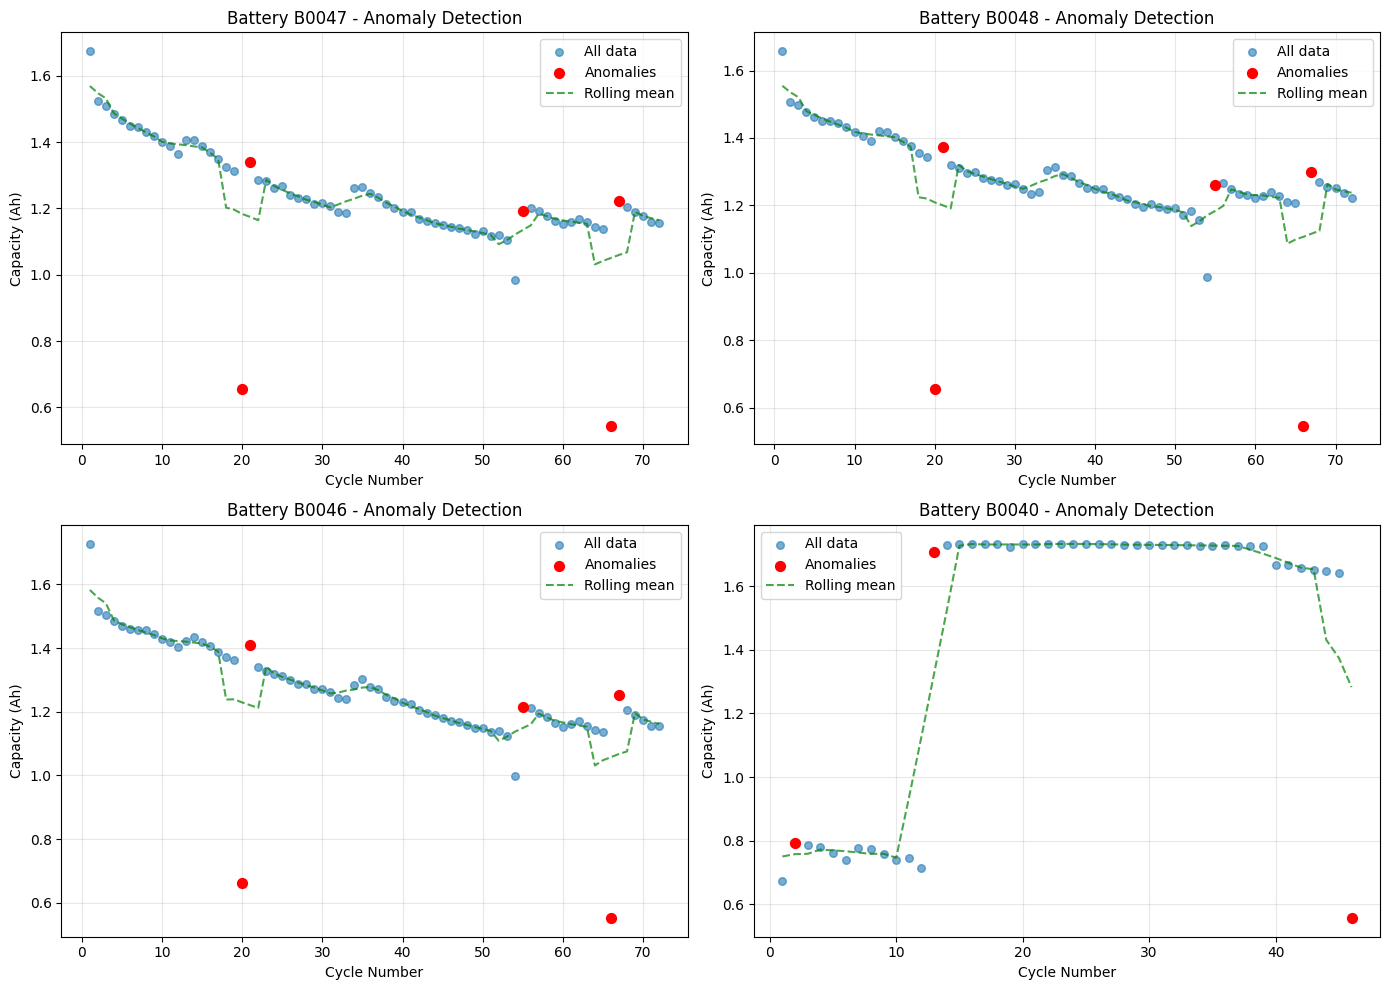

In [ ]:
# Visualize anomalies for problematic batteries
problematic_batteries = anomaly_df[anomaly_df['anomaly_percentage'] > 5]['battery_id'].head(4)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, battery_id in enumerate(problematic_batteries):
    battery_data = discharge_features_refined[
        discharge_features_refined['battery_id'] == battery_id
    ].copy()
    battery_data = detect_capacity_anomalies(battery_data)

    ax = axes[idx]

    # Plot all points
    ax.scatter(battery_data['cycle_number'],
              battery_data['calculated_capacity'],
              alpha=0.6, s=30, label='All data')

    # Highlight anomalies
    anomalies = battery_data[battery_data['is_anomaly']]
    ax.scatter(anomalies['cycle_number'],
              anomalies['calculated_capacity'],
              color='red', s=50, label='Anomalies', zorder=5)

    # Plot rolling mean
    ax.plot(battery_data['cycle_number'],
           battery_data['capacity_rolling_mean'],
           'g--', alpha=0.7, label='Rolling mean')

    ax.set_xlabel('Cycle Number')
    ax.set_ylabel('Capacity (Ah)')
    ax.set_title(f'Battery {battery_id} - Anomaly Detection')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **3.9 Apply Anomaly Filtering**

In [ ]:
def filter_anomalous_cycles(features_df: pd.DataFrame,
                          max_increase: float = 0.1,
                          max_decrease: float = 0.3) -> pd.DataFrame:
    """
    Filter out anomalous cycles from the dataset
    """
    filtered_data = []

    for battery_id in features_df['battery_id'].unique():
        battery_data = features_df[features_df['battery_id'] == battery_id].copy()
        battery_data = battery_data.sort_values('cycle_number')

        # Detect anomalies
        battery_data = detect_capacity_anomalies(battery_data, max_increase, max_decrease)

        # Keep only non-anomalous data
        clean_data = battery_data[~battery_data['is_anomaly']]

        # Recalculate cycle numbers after filtering
        clean_data = clean_data.copy()
        clean_data['cycle_number'] = range(1, len(clean_data) + 1)

        filtered_data.append(clean_data)

    return pd.concat(filtered_data, ignore_index=True)

# Apply filtering
discharge_features_clean = filter_anomalous_cycles(discharge_features_refined)

print(f"Original cycles: {len(discharge_features_refined)}")
print(f"Clean cycles: {len(discharge_features_clean)}")
print(f"Removed: {len(discharge_features_refined) - len(discharge_features_clean)} anomalous cycles")

Original cycles: 2490
Clean cycles: 2437
Removed: 53 anomalous cycles


### **4. Voltage Profile Extraction and Interpolation**

#### **4.1 Import Additional Libraries for Deep Learning Preparation**

In [ ]:
from scipy.interpolate import interp1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pickle

#### **4.2 Extract Full Voltage Profiles with Interpolation**

Sample interpolated profile:
Voltage shape: (100,)
Current shape: (100,)
Temperature shape: (100,)
Discharge duration: 6071.91 seconds


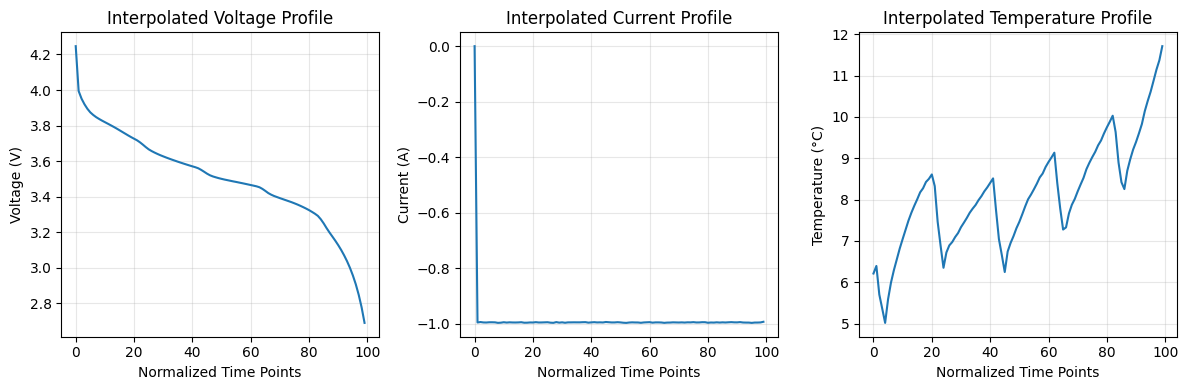

In [ ]:
def interpolate_discharge_profile(cycle_df: pd.DataFrame,
                                 n_points: int = 100,
                                 voltage_threshold: float = 2.7) -> Dict[str, np.ndarray]:
    """
    Interpolate discharge profile to fixed number of points using normalized time
    """
    if cycle_df is None or len(cycle_df) < 10:
        return None

    # Sort by time
    cycle_df = cycle_df.sort_values('Time').reset_index(drop=True)

    # Apply voltage threshold
    below_threshold = cycle_df['Voltage_measured'] < voltage_threshold
    if below_threshold.any():
        cutoff_idx = below_threshold.idxmax()
        cycle_df = cycle_df.iloc[:cutoff_idx + 1]

    if len(cycle_df) < 10:
        return None

    # Normalize time to [0, 1]
    time_normalized = (cycle_df['Time'] - cycle_df['Time'].min()) / (cycle_df['Time'].max() - cycle_df['Time'].min())

    # Create interpolation points
    time_interp = np.linspace(0, 1, n_points)

    # Interpolate each variable
    interpolated_data = {}

    # Voltage interpolation
    f_voltage = interp1d(time_normalized, cycle_df['Voltage_measured'], kind='linear', fill_value='extrapolate')
    interpolated_data['voltage'] = f_voltage(time_interp)

    # Current interpolation
    f_current = interp1d(time_normalized, cycle_df['Current_measured'], kind='linear', fill_value='extrapolate')
    interpolated_data['current'] = f_current(time_interp)

    # Temperature interpolation
    f_temp = interp1d(time_normalized, cycle_df['Temperature_measured'], kind='linear', fill_value='extrapolate')
    interpolated_data['temperature'] = f_temp(time_interp)

    # Time in seconds (actual discharge duration)
    interpolated_data['time_seconds'] = cycle_df['Time'].max()

    return interpolated_data

# Test interpolation on a sample cycle
sample_row = discharge_features_clean.iloc[0]
cycle_data = load_cycle_data(sample_row['filename'])
interpolated = interpolate_discharge_profile(cycle_data)

if interpolated:
    print("Sample interpolated profile:")
    print(f"Voltage shape: {interpolated['voltage'].shape}")
    print(f"Current shape: {interpolated['current'].shape}")
    print(f"Temperature shape: {interpolated['temperature'].shape}")
    print(f"Discharge duration: {interpolated['time_seconds']:.2f} seconds")

    # Visualize interpolation
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.plot(interpolated['voltage'])
    plt.xlabel('Normalized Time Points')
    plt.ylabel('Voltage (V)')
    plt.title('Interpolated Voltage Profile')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(interpolated['current'])
    plt.xlabel('Normalized Time Points')
    plt.ylabel('Current (A)')
    plt.title('Interpolated Current Profile')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(interpolated['temperature'])
    plt.xlabel('Normalized Time Points')
    plt.ylabel('Temperature (°C)')
    plt.title('Interpolated Temperature Profile')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

#### **4.3 Process All Clean Cycles with Interpolation**

In [ ]:
def create_sequence_dataset(features_df: pd.DataFrame,
                          n_points: int = 100,
                          include_features: List[str] = ['voltage', 'current', 'temperature']) -> Dict:
    """
    Create dataset with interpolated sequences for deep learning
    """
    sequences = {feat: [] for feat in include_features}
    capacities = []
    cycle_numbers = []
    battery_ids = []
    additional_features = []

    print(f"Processing {len(features_df)} cycles for sequence extraction...")

    for idx, row in tqdm(features_df.iterrows(), total=len(features_df), desc="Extracting sequences"):
        # Load cycle data
        cycle_data = load_cycle_data(row['filename'])

        # Interpolate profile
        interpolated = interpolate_discharge_profile(cycle_data, n_points=n_points)

        if interpolated is not None:
            # Add sequences
            for feat in include_features:
                sequences[feat].append(interpolated[feat])

            # Add target (capacity)
            capacities.append(row['calculated_capacity'])

            # Add metadata
            cycle_numbers.append(row['cycle_number'])
            battery_ids.append(row['battery_id'])

            # Add additional features
            additional_features.append([
                row['ambient_temperature'],
                row['duration_hours'],
                row['energy_wh'],
                row['voltage_drop'],
                row['temperature_mean'],
                row['temperature_range']
            ])

    # Convert to numpy arrays
    dataset = {
        'sequences': {feat: np.array(sequences[feat]) for feat in include_features},
        'capacities': np.array(capacities),
        'cycle_numbers': np.array(cycle_numbers),
        'battery_ids': np.array(battery_ids),
        'additional_features': np.array(additional_features),
        'feature_names': ['ambient_temp', 'duration_hours', 'energy_wh',
                         'voltage_drop', 'temp_mean', 'temp_range']
    }

    print(f"\nDataset created successfully!")
    print(f"Sequences shape: {dataset['sequences']['voltage'].shape}")
    print(f"Capacities shape: {dataset['capacities'].shape}")
    print(f"Additional features shape: {dataset['additional_features'].shape}")

    return dataset

# Create the sequence dataset
sequence_dataset = create_sequence_dataset(discharge_features_clean)

Processing 2437 cycles for sequence extraction...


Extracting sequences: 100%|██████████| 2437/2437 [00:13<00:00, 176.91it/s]


Dataset created successfully!
Sequences shape: (2437, 100)
Capacities shape: (2437,)
Additional features shape: (2437, 6)


#### **4.4 Visualize Battery Degradation with Interpolated Profiles**

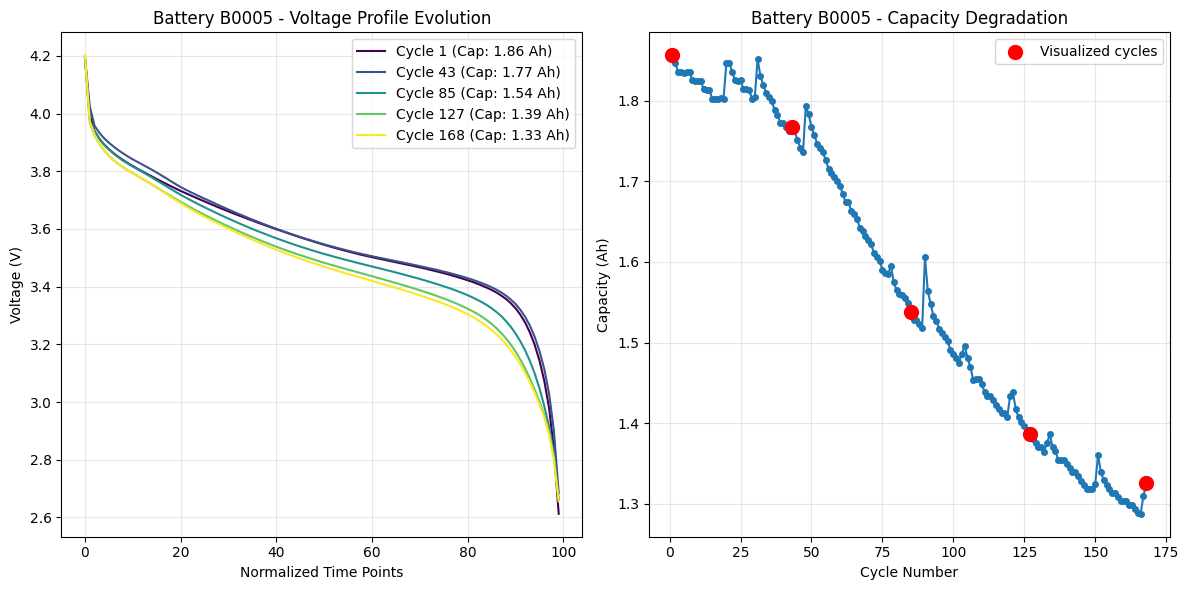

In [ ]:
# Select one battery to visualize degradation over time
battery_id = 'B0005'  # This showed good degradation pattern
battery_mask = sequence_dataset['battery_ids'] == battery_id

battery_voltages = sequence_dataset['sequences']['voltage'][battery_mask]
battery_capacities = sequence_dataset['capacities'][battery_mask]
battery_cycles = sequence_dataset['cycle_numbers'][battery_mask]

# Select cycles to visualize (early, middle, late)
n_cycles = len(battery_cycles)
cycle_indices = [0, n_cycles//4, n_cycles//2, 3*n_cycles//4, n_cycles-1]

plt.figure(figsize=(12, 6))

# Voltage profiles
plt.subplot(1, 2, 1)
colors = plt.cm.viridis(np.linspace(0, 1, len(cycle_indices)))
for i, idx in enumerate(cycle_indices):
    plt.plot(battery_voltages[idx], color=colors[i],
             label=f'Cycle {battery_cycles[idx]} (Cap: {battery_capacities[idx]:.2f} Ah)')
plt.xlabel('Normalized Time Points')
plt.ylabel('Voltage (V)')
plt.title(f'Battery {battery_id} - Voltage Profile Evolution')
plt.legend()
plt.grid(True, alpha=0.3)

# Capacity degradation
plt.subplot(1, 2, 2)
plt.plot(battery_cycles, battery_capacities, 'o-', markersize=4)
plt.scatter(battery_cycles[cycle_indices], battery_capacities[cycle_indices],
           color='red', s=100, zorder=5, label='Visualized cycles')
plt.xlabel('Cycle Number')
plt.ylabel('Capacity (Ah)')
plt.title(f'Battery {battery_id} - Capacity Degradation')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **4.5 Save Processed Dataset**

In [ ]:
# Save the complete dataset
output_file = os.path.join(BASE_PATH, "sequence_dataset_interpolated.pkl")
with open(output_file, 'wb') as f:
    pickle.dump(sequence_dataset, f)
print(f"Sequence dataset saved to: {output_file}")

# Also save the clean features dataframe
discharge_features_clean.to_csv(
    os.path.join(BASE_PATH, "discharge_features_clean.csv"),
    index=False
)
print(f"Clean features saved to: {os.path.join(BASE_PATH, 'discharge_features_clean.csv')}")

Sequence dataset saved to: /content/drive/MyDrive/ESCL/Projects/soh-prediction/sequence_dataset_interpolated.pkl
Clean features saved to: /content/drive/MyDrive/ESCL/Projects/soh-prediction/discharge_features_clean.csv


### **5. Deep Learning Data Preparation**

#### **5.1 Import Deep Learning Libraries**

In [ ]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam

#### **5.2 Create Train/Test Split by Battery**

In [ ]:
def create_battery_based_split(dataset: Dict, test_size: float = 0.2, random_state: int = 42):
    """
    Split data by battery ID to prevent data leakage
    """
    unique_batteries = np.unique(dataset['battery_ids'])

    # Split batteries into train and test
    train_batteries, test_batteries = train_test_split(
        unique_batteries,
        test_size=test_size,
        random_state=random_state
    )

    # Create masks
    train_mask = np.isin(dataset['battery_ids'], train_batteries)
    test_mask = np.isin(dataset['battery_ids'], test_batteries)

    # Split data
    train_data = {
        'sequences': {key: val[train_mask] for key, val in dataset['sequences'].items()},
        'capacities': dataset['capacities'][train_mask],
        'cycle_numbers': dataset['cycle_numbers'][train_mask],
        'battery_ids': dataset['battery_ids'][train_mask],
        'additional_features': dataset['additional_features'][train_mask]
    }

    test_data = {
        'sequences': {key: val[test_mask] for key, val in dataset['sequences'].items()},
        'capacities': dataset['capacities'][test_mask],
        'cycle_numbers': dataset['cycle_numbers'][test_mask],
        'battery_ids': dataset['battery_ids'][test_mask],
        'additional_features': dataset['additional_features'][test_mask]
    }

    print(f"Train batteries ({len(train_batteries)}): {sorted(train_batteries)}")
    print(f"Test batteries ({len(test_batteries)}): {sorted(test_batteries)}")
    print(f"\nTrain samples: {len(train_data['capacities'])}")
    print(f"Test samples: {len(test_data['capacities'])}")

    return train_data, test_data, train_batteries, test_batteries

# Create train/test split
train_data, test_data, train_batteries, test_batteries = create_battery_based_split(sequence_dataset)

Train batteries (24): [np.str_('B0005'), np.str_('B0006'), np.str_('B0007'), np.str_('B0018'), np.str_('B0025'), np.str_('B0026'), np.str_('B0027'), np.str_('B0028'), np.str_('B0031'), np.str_('B0032'), np.str_('B0033'), np.str_('B0034'), np.str_('B0036'), np.str_('B0039'), np.str_('B0041'), np.str_('B0042'), np.str_('B0043'), np.str_('B0044'), np.str_('B0045'), np.str_('B0047'), np.str_('B0048'), np.str_('B0053'), np.str_('B0055'), np.str_('B0056')]
Test batteries (6): [np.str_('B0029'), np.str_('B0030'), np.str_('B0038'), np.str_('B0040'), np.str_('B0046'), np.str_('B0054')]

Train samples: 2103
Test samples: 334


#### **5.3 Data Normalization**

In [ ]:
def normalize_sequences(train_data: Dict, test_data: Dict) -> Tuple[Dict, Dict, Dict]:
    """
    Normalize sequences and additional features
    """
    scalers = {}

    # Normalize sequences (voltage, current, temperature)
    for seq_type in train_data['sequences'].keys():
        scaler = MinMaxScaler()

        # Fit on training data
        train_seq = train_data['sequences'][seq_type]
        train_seq_reshaped = train_seq.reshape(-1, 1)
        scaler.fit(train_seq_reshaped)

        # Transform both train and test
        train_data['sequences'][seq_type] = scaler.transform(
            train_seq.reshape(-1, 1)
        ).reshape(train_seq.shape)

        test_seq = test_data['sequences'][seq_type]
        test_data['sequences'][seq_type] = scaler.transform(
            test_seq.reshape(-1, 1)
        ).reshape(test_seq.shape)

        scalers[f'seq_{seq_type}'] = scaler

    # Normalize additional features
    feature_scaler = StandardScaler()
    train_data['additional_features'] = feature_scaler.fit_transform(
        train_data['additional_features']
    )
    test_data['additional_features'] = feature_scaler.transform(
        test_data['additional_features']
    )
    scalers['additional_features'] = feature_scaler

    # Normalize capacities (target)
    capacity_scaler = MinMaxScaler()
    train_capacities = train_data['capacities'].reshape(-1, 1)
    test_capacities = test_data['capacities'].reshape(-1, 1)

    train_data['capacities_normalized'] = capacity_scaler.fit_transform(train_capacities).flatten()
    test_data['capacities_normalized'] = capacity_scaler.transform(test_capacities).flatten()
    scalers['capacity'] = capacity_scaler

    print("Data normalization completed")
    print(f"Voltage range: [{train_data['sequences']['voltage'].min():.3f}, {train_data['sequences']['voltage'].max():.3f}]")
    print(f"Current range: [{train_data['sequences']['current'].min():.3f}, {train_data['sequences']['current'].max():.3f}]")
    print(f"Temperature range: [{train_data['sequences']['temperature'].min():.3f}, {train_data['sequences']['temperature'].max():.3f}]")

    return train_data, test_data, scalers

# Normalize data
train_data, test_data, scalers = normalize_sequences(train_data, test_data)

Data normalization completed
Voltage range: [0.000, 1.000]
Current range: [0.000, 1.000]
Temperature range: [0.000, 1.000]


#### **5.4 Prepare Input Data for Models**

In [ ]:
def prepare_model_inputs(data: Dict, sequence_features: List[str] = ['voltage', 'current', 'temperature']):
    """
    Prepare inputs for deep learning models
    """
    # Stack sequence features
    sequence_list = [data['sequences'][feat] for feat in sequence_features]
    sequences_stacked = np.stack(sequence_list, axis=2)  # Shape: (samples, time_steps, features)

    # Additional features
    additional_features = data['additional_features']

    # Targets
    targets = data['capacities_normalized']

    return sequences_stacked, additional_features, targets

# Prepare training data
X_seq_train, X_add_train, y_train = prepare_model_inputs(train_data)
X_seq_test, X_add_test, y_test = prepare_model_inputs(test_data)

print(f"Training sequences shape: {X_seq_train.shape}")
print(f"Training additional features shape: {X_add_train.shape}")
print(f"Training targets shape: {y_train.shape}")
print(f"\nTest sequences shape: {X_seq_test.shape}")
print(f"Test additional features shape: {X_add_test.shape}")
print(f"Test targets shape: {y_test.shape}")

Training sequences shape: (2103, 100, 3)
Training additional features shape: (2103, 6)
Training targets shape: (2103,)

Test sequences shape: (334, 100, 3)
Test additional features shape: (334, 6)
Test targets shape: (334,)


#### **5.5 Create Data Visualization for Model Input**

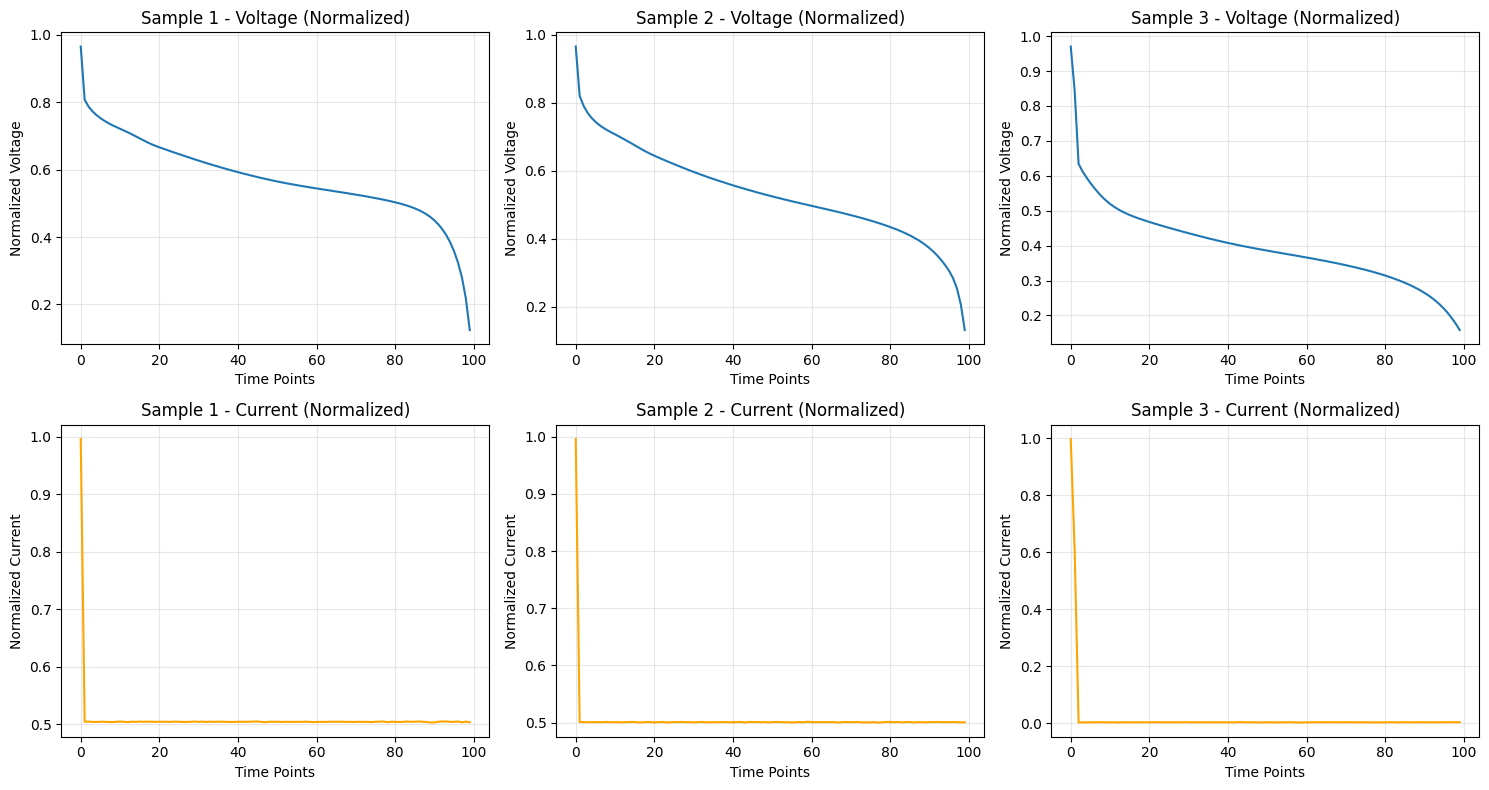

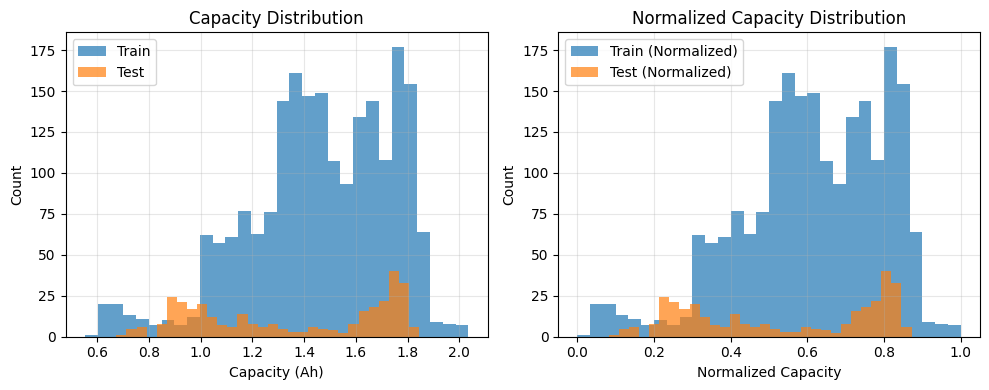

In [ ]:
# Visualize sample normalized sequences
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Select random samples
sample_indices = np.random.choice(len(X_seq_train), 3, replace=False)

for i, idx in enumerate(sample_indices):
    # Voltage
    axes[0, i].plot(X_seq_train[idx, :, 0])
    axes[0, i].set_title(f'Sample {i+1} - Voltage (Normalized)')
    axes[0, i].set_xlabel('Time Points')
    axes[0, i].set_ylabel('Normalized Voltage')
    axes[0, i].grid(True, alpha=0.3)

    # Current
    axes[1, i].plot(X_seq_train[idx, :, 1], color='orange')
    axes[1, i].set_title(f'Sample {i+1} - Current (Normalized)')
    axes[1, i].set_xlabel('Time Points')
    axes[1, i].set_ylabel('Normalized Current')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show capacity distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(train_data['capacities'], bins=30, alpha=0.7, label='Train')
plt.hist(test_data['capacities'], bins=30, alpha=0.7, label='Test')
plt.xlabel('Capacity (Ah)')
plt.ylabel('Count')
plt.title('Capacity Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(y_train, bins=30, alpha=0.7, label='Train (Normalized)')
plt.hist(y_test, bins=30, alpha=0.7, label='Test (Normalized)')
plt.xlabel('Normalized Capacity')
plt.ylabel('Count')
plt.title('Normalized Capacity Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **5.6 Save Prepared Data**

In [ ]:
# Save prepared data for models
prepared_data = {
    'X_seq_train': X_seq_train,
    'X_add_train': X_add_train,
    'y_train': y_train,
    'X_seq_test': X_seq_test,
    'X_add_test': X_add_test,
    'y_test': y_test,
    'train_data': train_data,
    'test_data': test_data,
    'scalers': scalers,
    'train_batteries': train_batteries,
    'test_batteries': test_batteries
}

output_file = os.path.join(BASE_PATH, "prepared_dl_data.pkl")
with open(output_file, 'wb') as f:
    pickle.dump(prepared_data, f)
print(f"Prepared data saved to: {output_file}")

Prepared data saved to: /content/drive/MyDrive/ESCL/Projects/soh-prediction/prepared_dl_data.pkl


### **6. Baseline Model Implementation**

#### **6.1 Import Baseline Model Libraries**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

#### **6.2 Prepare Features for Traditional ML Models**

In [ ]:
def prepare_ml_features(features_df: pd.DataFrame, sequence_dataset: Dict) -> pd.DataFrame:
    """
    Prepare features for traditional ML models (RF, XGBoost)
    Extract statistical features from sequences instead of using raw sequences
    """
    ml_features = []

    for i in range(len(sequence_dataset['battery_ids'])):
        features = {}

        # Voltage profile statistics
        voltage_seq = sequence_dataset['sequences']['voltage'][i]
        features['voltage_mean'] = np.mean(voltage_seq)
        features['voltage_std'] = np.std(voltage_seq)
        features['voltage_start'] = voltage_seq[0]
        features['voltage_end'] = voltage_seq[-1]
        features['voltage_drop'] = voltage_seq[0] - voltage_seq[-1]
        features['voltage_drop_rate'] = (voltage_seq[0] - voltage_seq[-1]) / len(voltage_seq)

        # Find voltage at different discharge percentages
        for pct in [25, 50, 75]:
            idx = int(len(voltage_seq) * pct / 100)
            features[f'voltage_{pct}pct'] = voltage_seq[idx]

        # Current profile statistics
        current_seq = sequence_dataset['sequences']['current'][i]
        features['current_mean'] = np.mean(current_seq)
        features['current_std'] = np.std(current_seq)

        # Temperature profile statistics
        temp_seq = sequence_dataset['sequences']['temperature'][i]
        features['temp_mean'] = np.mean(temp_seq)
        features['temp_std'] = np.std(temp_seq)
        features['temp_range'] = np.max(temp_seq) - np.min(temp_seq)

        # Additional features
        for j, feat_name in enumerate(sequence_dataset['feature_names']):
            features[feat_name] = sequence_dataset['additional_features'][i, j]

        # Add target
        features['capacity'] = sequence_dataset['capacities'][i]
        features['battery_id'] = sequence_dataset['battery_ids'][i]
        features['cycle_number'] = sequence_dataset['cycle_numbers'][i]

        ml_features.append(features)

    return pd.DataFrame(ml_features)

# Prepare features for ML models
ml_features_df = prepare_ml_features(discharge_features_clean, sequence_dataset)

print("ML Features shape:", ml_features_df.shape)
print("\nFeature columns:")
print(ml_features_df.columns.tolist())

ML Features shape: (2437, 20)

Feature columns:
['voltage_mean', 'voltage_std', 'voltage_start', 'voltage_end', 'voltage_drop', 'voltage_drop_rate', 'voltage_25pct', 'voltage_50pct', 'voltage_75pct', 'current_mean', 'current_std', 'temp_mean', 'temp_std', 'temp_range', 'ambient_temp', 'duration_hours', 'energy_wh', 'capacity', 'battery_id', 'cycle_number']


#### **6.3 Create Train/Test Split for ML Models**

In [ ]:
# Use same battery split as deep learning models
train_mask_ml = ml_features_df['battery_id'].isin(train_batteries)
test_mask_ml = ml_features_df['battery_id'].isin(test_batteries)

# Prepare features and targets
feature_cols = [col for col in ml_features_df.columns
                if col not in ['capacity', 'battery_id', 'cycle_number']]

X_train_ml = ml_features_df.loc[train_mask_ml, feature_cols]
y_train_ml = ml_features_df.loc[train_mask_ml, 'capacity']

X_test_ml = ml_features_df.loc[test_mask_ml, feature_cols]
y_test_ml = ml_features_df.loc[test_mask_ml, 'capacity']

print(f"Training samples: {len(X_train_ml)}")
print(f"Test samples: {len(X_test_ml)}")
print(f"Number of features: {len(feature_cols)}")

# Scale features
from sklearn.preprocessing import StandardScaler
scaler_ml = StandardScaler()
X_train_ml_scaled = scaler_ml.fit_transform(X_train_ml)
X_test_ml_scaled = scaler_ml.transform(X_test_ml)

Training samples: 2103
Test samples: 334
Number of features: 17


#### **6.6 Simple LSTM Model (Baseline)**

In [ ]:
def build_simple_lstm_model(input_shape, learning_rate=0.001):
    """
    Build a simple LSTM model similar to kaggle baseline
    """
    model = Sequential([
        LSTM(50, activation='relu', input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        LSTM(50, activation='relu'),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )

    return model

# Create validation split from training data
X_seq_train_split, X_seq_val_split, X_add_train_split, X_add_val_split, y_train_split, y_val_split = train_test_split(
    X_seq_train, X_add_train, y_train, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_seq_train_split)}")
print(f"Validation samples: {len(X_seq_val_split)}")

# Build and train simple LSTM
simple_lstm = build_simple_lstm_model((X_seq_train.shape[1], X_seq_train.shape[2]))

print("Training Simple LSTM...")
lstm_history = simple_lstm.fit(
    X_seq_train_split,  # Using only sequences, no additional features
    y_train_split,
    validation_data=(X_seq_val_split, y_val_split),
    epochs=50,
    batch_size=32,
    verbose=0,
    callbacks=[
        callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=1)
    ]
)

# Predictions
lstm_pred_normalized = simple_lstm.predict(X_seq_test)
lstm_pred_test = scalers['capacity'].inverse_transform(
    lstm_pred_normalized.reshape(-1, 1)
).flatten()

# Evaluate
lstm_metrics = {
    'Model': 'Simple LSTM',
    'MAE (Ah)': mean_absolute_error(y_test_ml, lstm_pred_test),
    'RMSE (Ah)': np.sqrt(mean_squared_error(y_test_ml, lstm_pred_test)),
    'R²': r2_score(y_test_ml, lstm_pred_test),
    'MAPE (%)': np.mean(np.abs((y_test_ml - lstm_pred_test) / y_test_ml)) * 100
}

print(f"\nSimple LSTM Test Performance:")
print(f"MAE: {lstm_metrics['MAE (Ah)']:.4f} Ah")
print(f"RMSE: {lstm_metrics['RMSE (Ah)']:.4f} Ah")
print(f"R²: {lstm_metrics['R²']:.4f}")

Training samples: 1682
Validation samples: 421
Training Simple LSTM...
Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 24.
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step

Simple LSTM Test Performance:
MAE: 0.1579 Ah
RMSE: 0.1996 Ah
R²: 0.6920


### **7. ML / DL Model Implementation**

#### **7.1 Train Random Forest Model**

In [ ]:
# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")
rf_model.fit(X_train_ml_scaled, y_train_ml)

# Predictions
rf_pred_train = rf_model.predict(X_train_ml_scaled)
rf_pred_test = rf_model.predict(X_test_ml_scaled)

# Evaluate
rf_metrics = {
    'Model': 'Random Forest',
    'MAE (Ah)': mean_absolute_error(y_test_ml, rf_pred_test),
    'RMSE (Ah)': np.sqrt(mean_squared_error(y_test_ml, rf_pred_test)),
    'R²': r2_score(y_test_ml, rf_pred_test),
    'MAPE (%)': np.mean(np.abs((y_test_ml - rf_pred_test) / y_test_ml)) * 100
}

print(f"\nRandom Forest Test Performance:")
print(f"MAE: {rf_metrics['MAE (Ah)']:.4f} Ah")
print(f"RMSE: {rf_metrics['RMSE (Ah)']:.4f} Ah")
print(f"R²: {rf_metrics['R²']:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

Training Random Forest...

Random Forest Test Performance:
MAE: 0.0566 Ah
RMSE: 0.0767 Ah
R²: 0.9545

Top 10 Most Important Features:
           feature  importance
16       energy_wh    0.969790
15  duration_hours    0.006863
9     current_mean    0.006633
10     current_std    0.004314
4     voltage_drop    0.002134
6    voltage_25pct    0.002000
7    voltage_50pct    0.001682
11       temp_mean    0.001445
1      voltage_std    0.001436
2    voltage_start    0.001160


#### **7.2 Train XGBoost Model**

In [ ]:
# Train XGBoost
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

print("Training XGBoost...")
xgb_model.fit(
    X_train_ml_scaled, y_train_ml,
    eval_set=[(X_test_ml_scaled, y_test_ml)],
    verbose=False
)

# Predictions
xgb_pred_test = xgb_model.predict(X_test_ml_scaled)

# Evaluate
xgb_metrics = {
    'Model': 'XGBoost',
    'MAE (Ah)': mean_absolute_error(y_test_ml, xgb_pred_test),
    'RMSE (Ah)': np.sqrt(mean_squared_error(y_test_ml, xgb_pred_test)),
    'R²': r2_score(y_test_ml, xgb_pred_test),
    'MAPE (%)': np.mean(np.abs((y_test_ml - xgb_pred_test) / y_test_ml)) * 100
}

print(f"\nXGBoost Test Performance:")
print(f"MAE: {xgb_metrics['MAE (Ah)']:.4f} Ah")
print(f"RMSE: {xgb_metrics['RMSE (Ah)']:.4f} Ah")
print(f"R²: {xgb_metrics['R²']:.4f}")

Training XGBoost...

XGBoost Test Performance:
MAE: 0.0533 Ah
RMSE: 0.0682 Ah
R²: 0.9640


#### **7.3 TCN (Temporal Convolutional Network) Implementation**

In [ ]:
# Install keras-tcn if needed
# !pip install keras-tcn

from tensorflow.keras.layers import Dense, Dropout, Input, Concatenate, BatchNormalization
from tcn import TCN

def build_tcn_model(sequence_shape, additional_features_shape,
                   tcn_filters=64, tcn_kernel_size=3, tcn_dilations=[1, 2, 4, 8, 16],
                   dense_units=[128, 64], dropout_rate=0.2):
    """
    Build TCN model with additional features
    """
    # Sequence input
    sequence_input = Input(shape=sequence_shape, name='sequence_input')

    # TCN layers
    tcn_out = TCN(
        nb_filters=tcn_filters,
        kernel_size=tcn_kernel_size,
        dilations=tcn_dilations,
        return_sequences=False,
        activation='relu',
        dropout_rate=dropout_rate
    )(sequence_input)

    # Additional features input
    additional_input = Input(shape=(additional_features_shape,), name='additional_input')

    # Combine TCN output with additional features
    combined = Concatenate()([tcn_out, additional_input])

    # Dense layers
    x = combined
    for units in dense_units:
        x = Dense(units, activation='relu')(x)
        x = BatchNormalization()(x)
        x = Dropout(dropout_rate)(x)

    # Output layer
    output = Dense(1, activation='sigmoid', name='capacity_output')(x)

    # Create model
    model = models.Model(
        inputs=[sequence_input, additional_input],
        outputs=output
    )

    return model

# Build TCN model
tcn_model = build_tcn_model(
    sequence_shape=(X_seq_train.shape[1], X_seq_train.shape[2]),
    additional_features_shape=X_add_train.shape[1]
)

tcn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("TCN Model Summary:")
tcn_model.summary()

TCN Model Summary:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 100, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn (TCN)           │ (None, 64)        │    112,064 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ additional_input    │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 70)        │          0 │ tcn[0][0],        │
│ (Concatenate)       │                   │            │ additional_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │      9,088 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense_8[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capacity_output     │ (None, 1)         │         65 │ dropout_9[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 130,241 (508.75 KB)

 Trainable params: 129,857 (507.25 KB)

 Non-trainable params: 384 (1.50 KB)

#### **7.4 BiLSTM (Bidirectional LSTM) Implementation**

In [ ]:
from tensorflow.keras.layers import LSTM, Bidirectional

def build_bilstm_model(sequence_shape, additional_features_shape,
                      lstm_units=[64, 32], dense_units=[128, 64],
                      dropout_rate=0.2):
    """
    Build Bidirectional LSTM model with additional features
    """
    # Sequence input
    sequence_input = Input(shape=sequence_shape, name='sequence_input')

    # BiLSTM layers
    x = sequence_input
    for i, units in enumerate(lstm_units):
        return_sequences = (i < len(lstm_units) - 1)
        x = Bidirectional(
            LSTM(units, return_sequences=return_sequences, dropout=dropout_rate)
        )(x)
        if return_sequences:
            x = BatchNormalization()(x)

    # Additional features input
    additional_input = Input(shape=(additional_features_shape,), name='additional_input')

    # Combine LSTM output with additional features
    combined = Concatenate()([x, additional_input])

    # Dense layers
    x = combined
    for units in dense_units:
        x = Dense(units, activation='relu')(x)
        x = BatchNormalization()(x)
        x = Dropout(dropout_rate)(x)

    # Output layer
    output = Dense(1, activation='sigmoid', name='capacity_output')(x)

    # Create model
    model = models.Model(
        inputs=[sequence_input, additional_input],
        outputs=output
    )

    return model

# Build BiLSTM model
bilstm_model = build_bilstm_model(
    sequence_shape=(X_seq_train.shape[1], X_seq_train.shape[2]),
    additional_features_shape=X_add_train.shape[1]
)

bilstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("\nBiLSTM Model Summary:")
bilstm_model.summary()


BiLSTM Model Summary:


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 100, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 100, 128)  │     34,816 │ sequence_input[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 128)  │        512 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     41,216 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ additional_input    │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 70)        │          0 │ bidirectional_1[… │
│ (Concatenate)       │                   │            │ additional_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │      9,088 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      8,256 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_11[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capacity_output     │ (None, 1)         │         65 │ dropout_11[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 94,721 (370.00 KB)

 Trainable params: 94,081 (367.50 KB)

 Non-trainable params: 640 (2.50 KB)

#### **7.5 Define Training Callbacks**

In [ ]:
def create_callbacks(model_name):
    """
    Create callbacks for model training
    """
    callbacks_list = [
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=os.path.join(BASE_PATH, f'{model_name}_best.h5'),
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]
    return callbacks_list

#### **7.6 Train TCN Model**

In [ ]:
# Create validation split from training data
X_seq_train_split, X_seq_val_split, X_add_train_split, X_add_val_split, y_train_split, y_val_split = train_test_split(
    X_seq_train, X_add_train, y_train, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_seq_train_split)}")
print(f"Validation samples: {len(X_seq_val_split)}")

# Train TCN model
tcn_callbacks = create_callbacks('tcn_model')

tcn_history = tcn_model.fit(
    [X_seq_train_split, X_add_train_split],
    y_train_split,
    validation_data=([X_seq_val_split, X_add_val_split], y_val_split),
    epochs=100,
    batch_size=32,
    callbacks=tcn_callbacks,
    verbose=1
)

Training samples: 1682
Validation samples: 421
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 0.0910 - mae: 0.2418
Epoch 1: val_loss improved from inf to 0.08153, saving model to /content/drive/MyDrive/ESCL/Projects/soh-prediction/tcn_model_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 272ms/step - loss: 0.0908 - mae: 0.2415 - val_loss: 0.0815 - val_mae: 0.2527 - learning_rate: 0.0010
Epoch 2/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0544 - mae: 0.1879
Epoch 2: val_loss improved from 0.08153 to 0.02745, saving model to /content/drive/MyDrive/ESCL/Projects/soh-prediction/tcn_model_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - loss: 0.0541 - mae: 0.1875 - val_loss: 0.0274 - val_mae: 0.1329 - learning_rate: 0.0010
Epoch 3/100
49/53 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0386 - mae: 0.1562
Epoch 3: val_loss improved from 0.02745 to 0.01691, saving model to /content/drive/MyDrive/ESCL/Projects/soh-prediction/tcn_model_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0386 - mae: 0.1562 - val_loss: 0.0169 - val_mae: 0.1056 - learning_rate: 0.0010
Epoch 4/100
50/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0355 - mae: 0.1514
Epoch 4: val_loss did not improve from 0.01691
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0353 - mae: 0.1509 - val_loss: 0.0278 - val_mae: 0.1372 - learning_rate: 0.0010
Epoch 5/100
48/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0320 - mae: 0.1413
Epoch 5: val_loss did not improve from 0.01691
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0317 - mae: 0.1408 - val_loss: 0.0172 - val_mae: 0.1056 - learning_rate: 0.0010
Epoch 6/100
50/53 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0288 - mae: 0.1346
Epoch 6: val_loss did not improve from 0.01691
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0286 - mae: 0.1344 - val_loss: 0.0186 - val_mae: 0.1139 - learning_rate: 0.0010
Epoch 7/100
51/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0254 - mae: 0.1257
Epoch 7: val_loss i

53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0253 - mae: 0.1256 - val_loss: 0.0164 - val_mae: 0.1053 - learning_rate: 0.0010
Epoch 8/100
49/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0243 - mae: 0.1239
Epoch 8: val_loss did not improve from 0.01638
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0243 - mae: 0.1238 - val_loss: 0.0195 - val_mae: 0.1163 - learning_rate: 0.0010
Epoch 9/100
51/53 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0220 - mae: 0.1177
Epoch 9: val_loss did not improve from 0.01638
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0219 - mae: 0.1175 - val_loss: 0.0315 - val_mae: 0.1502 - learning_rate: 0.0010
Epoch 10/100
48/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0191 - mae: 0.1078
Epoch 10: val_loss did not improve from 0.01638
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0191 - mae: 0.1077 - val_loss: 0.0452 - val_mae: 0.1851 - learning_rate: 0.0010
Epoch 11/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0167 - mae: 0.1011 
Epoch 11: val_lo

...

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0015 - mae: 0.0307 - val_loss: 2.0837e-04 - val_mae: 0.0105 - learning_rate: 1.2500e-04
Epoch 76/100
46/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0018 - mae: 0.0325
Epoch 76: val_loss improved from 0.00021 to 0.00021, saving model to /content/drive/MyDrive/ESCL/Projects/soh-prediction/tcn_model_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0018 - mae: 0.0328 - val_loss: 2.0836e-04 - val_mae: 0.0107 - learning_rate: 1.2500e-04
Epoch 77/100
51/53 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0017 - mae: 0.0336
Epoch 77: val_loss improved from 0.00021 to 0.00019, saving model to /content/drive/MyDrive/ESCL/Projects/soh-prediction/tcn_model_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0017 - mae: 0.0336 - val_loss: 1.9474e-04 - val_mae: 0.0103 - learning_rate: 1.2500e-04
Epoch 78/100
47/53 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0022 - mae: 0.0374
Epoch 78: val_loss did not improve from 0.00019
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0021 - mae: 0.0370 - val_loss: 2.0694e-04 - val_mae: 0.0105 - learning_rate: 1.2500e-04
Epoch 79/100
46/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0019 - mae: 0.0336
Epoch 79: val_loss did not improve from 0.00019
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0019 - mae: 0.0339 - val_loss: 2.3479e-04 - val_mae: 0.0112 - learning_rate: 1.2500e-04
Epoch 80/100
50/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - mae: 0.0364
Epoch 80: val_loss did not improve from 0.00019
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0021 - mae: 0.0363 - val_loss: 2.0278e-04 - val_mae: 0.0105 - learning_rate: 1.2500e-04
Epoch 81/100
45/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0018 - mae: 0.0336 - val_loss: 1.9288e-04 - val_mae: 0.0102 - learning_rate: 6.2500e-05
Epoch 89/100
46/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0016 - mae: 0.0316
Epoch 89: val_loss did not improve from 0.00019
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0017 - mae: 0.0320 - val_loss: 2.0074e-04 - val_mae: 0.0103 - learning_rate: 6.2500e-05
Epoch 90/100
47/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0020 - mae: 0.0360
Epoch 90: val_loss did not improve from 0.00019
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0020 - mae: 0.0360 - val_loss: 2.0109e-04 - val_mae: 0.0104 - learning_rate: 6.2500e-05
Epoch 91/100
46/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0016 - mae: 0.0306
Epoch 91: val_loss did not improve from 0.00019
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0016 - mae: 0.0310 - val_loss: 1.9641e-04 - val_mae: 0.0104 - learning_rate: 6.2500e-05
Epoch 92/100
46/53 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0016 - mae: 0.0304 - val_loss: 1.8948e-04 - val_mae: 0.0101 - learning_rate: 3.1250e-05
Epoch 97/100
48/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0016 - mae: 0.0313
Epoch 97: val_loss did not improve from 0.00019
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0016 - mae: 0.0314 - val_loss: 1.9435e-04 - val_mae: 0.0102 - learning_rate: 3.1250e-05
Epoch 98/100
46/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026 - mae: 0.0412
Epoch 98: val_loss did not improve from 0.00019
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0025 - mae: 0.0403 - val_loss: 1.9446e-04 - val_mae: 0.0103 - learning_rate: 3.1250e-05
Epoch 99/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0017 - mae: 0.0332
Epoch 99: val_loss did not improve from 0.00019
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017 - mae: 0.0331 - val_loss: 1.9633e-04 - val_mae: 0.0104 - learning_rate: 3.1250e-05
Epoch 100/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 

#### **7.6 Train BiLSTM Model**

In [ ]:
# Train BiLSTM model
bilstm_callbacks = create_callbacks('bilstm_model')

bilstm_history = bilstm_model.fit(
    [X_seq_train_split, X_add_train_split],
    y_train_split,
    validation_data=([X_seq_val_split, X_add_val_split], y_val_split),
    epochs=100,
    batch_size=32,
    callbacks=bilstm_callbacks,
    verbose=1
)

Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0692 - mae: 0.2088
Epoch 1: val_loss improved from inf to 0.01276, saving model to /content/drive/MyDrive/ESCL/Projects/soh-prediction/bilstm_model_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.0689 - mae: 0.2083 - val_loss: 0.0128 - val_mae: 0.0923 - learning_rate: 0.0010
Epoch 2/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0305 - mae: 0.1375
Epoch 2: val_loss did not improve from 0.01276
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0304 - mae: 0.1372 - val_loss: 0.0136 - val_mae: 0.0948 - learning_rate: 0.0010
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0204 - mae: 0.1139
Epoch 3: val_loss did not improve from 0.01276
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0204 - mae: 0.1138 - val_loss: 0.0132 - val_mae: 0.0940 - learning_rate: 0.0010
Epoch 4/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0183 - mae: 0.1076
Epoch 4: val_loss improved from 0.01276 to 0.00632, saving model to /content/drive/MyDrive/ESCL/Projects/soh-prediction/bilstm_model_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0182 - mae: 0.1075 - val_loss: 0.0063 - val_mae: 0.0650 - learning_rate: 0.0010
Epoch 5/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0140 - mae: 0.0926
Epoch 5: val_loss improved from 0.00632 to 0.00425, saving model to /content/drive/MyDrive/ESCL/Projects/soh-prediction/bilstm_model_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0140 - mae: 0.0924 - val_loss: 0.0043 - val_mae: 0.0542 - learning_rate: 0.0010
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0113 - mae: 0.0831
Epoch 6: val_loss improved from 0.00425 to 0.00275, saving model to /content/drive/MyDrive/ESCL/Projects/soh-prediction/bilstm_model_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0113 - mae: 0.0830 - val_loss: 0.0028 - val_mae: 0.0435 - learning_rate: 0.0010
Epoch 7/100
51/53 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0094 - mae: 0.0753
Epoch 7: val_loss improved from 0.00275 to 0.00204, saving model to /content/drive/MyDrive/ESCL/Projects/soh-prediction/bilstm_model_best.h5


...

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.0015 - mae: 0.0298 - val_loss: 1.7038e-04 - val_mae: 0.0099 - learning_rate: 3.1250e-05
Epoch 80/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0015 - mae: 0.0306
Epoch 80: val_loss improved from 0.00017 to 0.00017, saving model to /content/drive/MyDrive/ESCL/Projects/soh-prediction/bilstm_model_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0015 - mae: 0.0307 - val_loss: 1.6650e-04 - val_mae: 0.0099 - learning_rate: 3.1250e-05
Epoch 81/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0017 - mae: 0.0325
Epoch 81: val_loss did not improve from 0.00017
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0017 - mae: 0.0325 - val_loss: 1.7529e-04 - val_mae: 0.0100 - learning_rate: 3.1250e-05
Epoch 82/100
51/53 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0016 - mae: 0.0316
Epoch 82: val_loss did not improve from 0.00017
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0016 - mae: 0.0317 - val_loss: 1.7501e-04 - val_mae: 0.0101 - learning_rate: 3.1250e-05
Epoch 83/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0022 - mae: 0.0374
Epoch 83: val_loss did not improve from 0.00017
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0022 - mae: 0.0373 - val_loss: 1.7236e-04 - val_mae: 0.0100 - learning_rate: 3.1250e-05
Epoch 84/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - los

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0018 - mae: 0.0341 - val_loss: 1.6595e-04 - val_mae: 0.0099 - learning_rate: 3.1250e-05
Epoch 89/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0019 - mae: 0.0346
Epoch 89: val_loss did not improve from 0.00017
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0019 - mae: 0.0346 - val_loss: 1.6834e-04 - val_mae: 0.0099 - learning_rate: 1.5625e-05
Epoch 90/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0022 - mae: 0.0380
Epoch 90: val_loss did not improve from 0.00017
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0022 - mae: 0.0380 - val_loss: 1.6961e-04 - val_mae: 0.0099 - learning_rate: 1.5625e-05
Epoch 91/100
51/53 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0016 - mae: 0.0307
Epoch 91: val_loss improved from 0.00017 to 0.00016, saving model to /content/drive/MyDrive/ESCL/Projects/soh-prediction/bilstm_model_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0016 - mae: 0.0308 - val_loss: 1.6416e-04 - val_mae: 0.0097 - learning_rate: 1.5625e-05
Epoch 92/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0018 - mae: 0.0323
Epoch 92: val_loss did not improve from 0.00016
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0018 - mae: 0.0324 - val_loss: 1.7096e-04 - val_mae: 0.0099 - learning_rate: 1.5625e-05
Epoch 93/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0018 - mae: 0.0332
Epoch 93: val_loss did not improve from 0.00016
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0018 - mae: 0.0332 - val_loss: 1.6697e-04 - val_mae: 0.0099 - learning_rate: 1.5625e-05
Epoch 94/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0020 - mae: 0.0348
Epoch 94: val_loss improved from 0.00016 to 0.00016, saving model to /content/drive/MyDrive/ESCL/Projects/soh-prediction/bilstm_model_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0020 - mae: 0.0348 - val_loss: 1.6169e-04 - val_mae: 0.0098 - learning_rate: 1.5625e-05
Epoch 95/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0016 - mae: 0.0316
Epoch 95: val_loss did not improve from 0.00016
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0016 - mae: 0.0316 - val_loss: 1.7360e-04 - val_mae: 0.0101 - learning_rate: 1.5625e-05
Epoch 96/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0016 - mae: 0.0315
Epoch 96: val_loss did not improve from 0.00016
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0017 - mae: 0.0315 - val_loss: 1.6866e-04 - val_mae: 0.0099 - learning_rate: 1.5625e-05
Epoch 97/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0016 - mae: 0.0316
Epoch 97: val_loss did not improve from 0.00016
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0016 - mae: 0.0317 - val_loss: 1.6852e-04 - val_mae: 0.0100 - learning_rate: 1.5625e-05
Epoch 98/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - los

### **8. Model Evaluation and Comparison**


#### **8.1 Machine Learning Model Evaluation**

##### **8.1.1 Comparasion Model**

In [ ]:
# Create comparison table for Machine Learning models
baseline_comparison = pd.DataFrame([
    rf_metrics,
    xgb_metrics,
])

print("\nComplete Model Comparison:")
print("=" * 70)
display(baseline_comparison.style.format({
    'MAE (Ah)': '{:.4f}',
    'RMSE (Ah)': '{:.4f}',
    'R²': '{:.4f}',
    'MAPE (%)': '{:.2f}'
}))


Complete Model Comparison:


,Model,MAE (Ah),RMSE (Ah),R²,MAPE (%)
0,Random Forest,0.0566,0.0767,0.9545,5.30
1,XGBoost,0.0533,0.0682,0.9640,4.90


##### **8.1.2 Create Prediction vs Actual Plots for ML models**

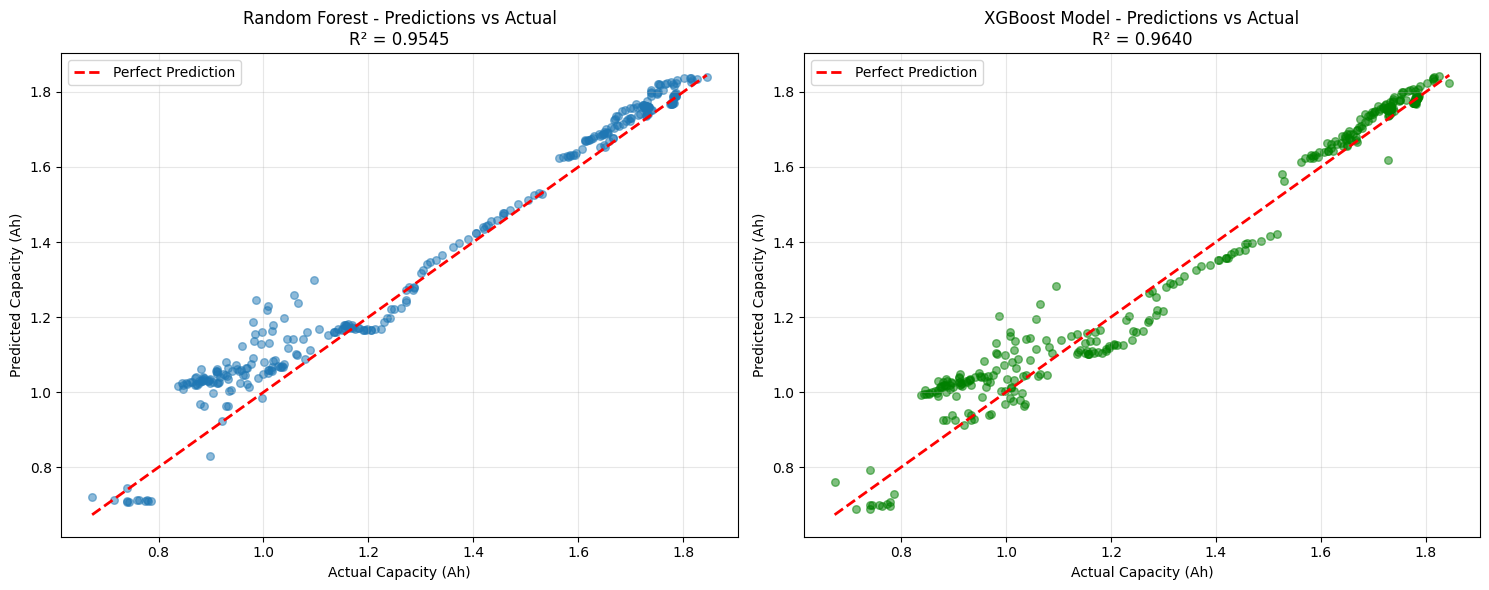

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Random Forest Plot
axes[0].scatter(y_test_ml, rf_pred_test, alpha=0.5, s=30)
axes[0].plot([y_test_ml.min(), y_test_ml.max()],
             [y_test_ml.min(), y_test_ml.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Capacity (Ah)')
axes[0].set_ylabel('Predicted Capacity (Ah)')
axes[0].set_title(f'Random Forest - Predictions vs Actual\nR² = {rf_metrics["R²"]:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# XGBoost Plot
axes[1].scatter(y_test_ml, xgb_pred_test, alpha=0.5, s=30, color='green')
axes[1].plot([y_test_ml.min(), y_test_ml.max()],
             [y_test_ml.min(), y_test_ml.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Capacity (Ah)')
axes[1].set_ylabel('Predicted Capacity (Ah)')
axes[1].set_title(f'XGBoost Model - Predictions vs Actual\nR² = {xgb_metrics["R²"]:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### 8.1.3 Create Error Distribution Plots

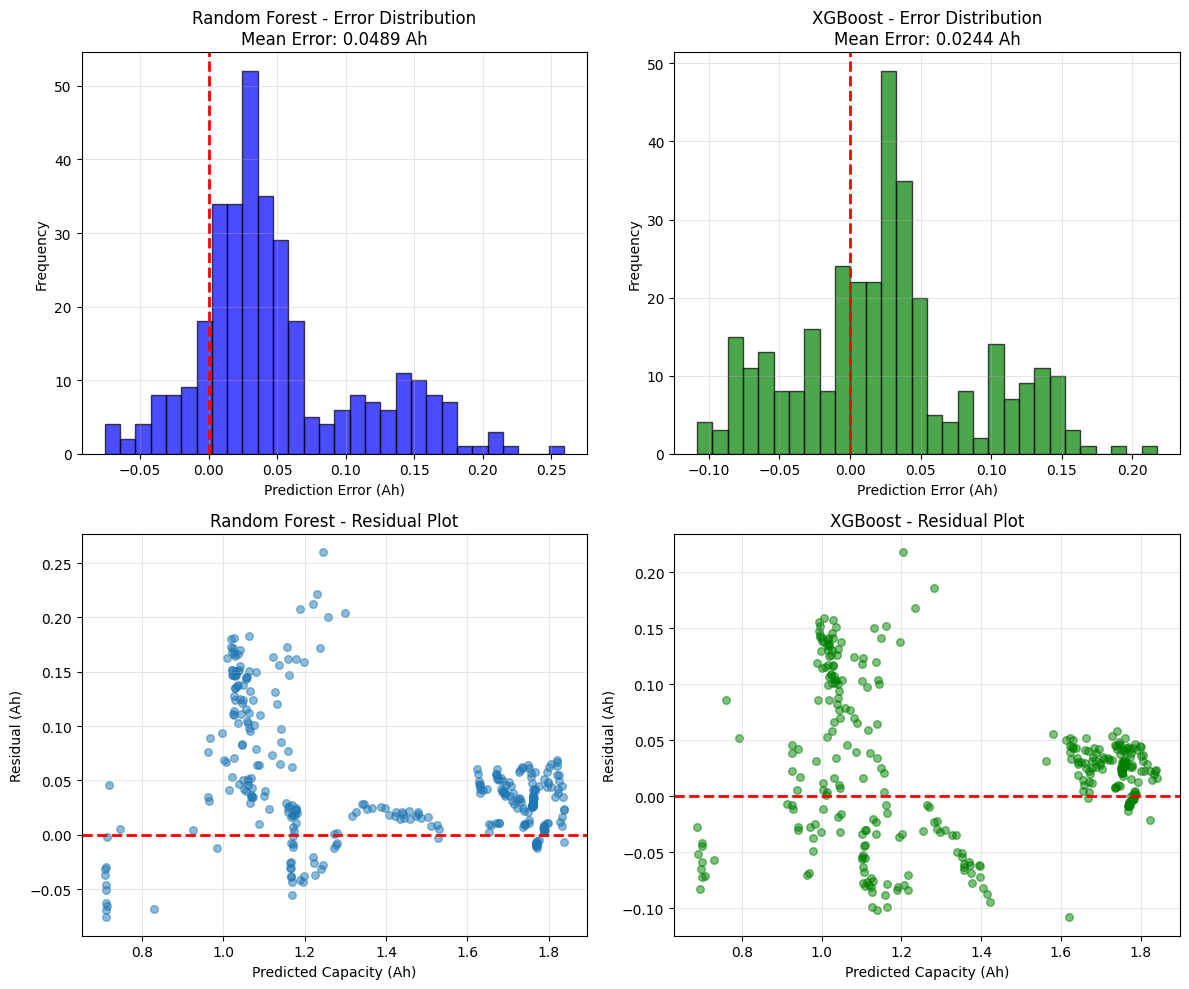

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# RF Error Distribution
rf_errors = rf_pred_test - y_test_ml
axes[0, 0].hist(rf_errors, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Prediction Error (Ah)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Random Forest - Error Distribution\nMean Error: {np.mean(rf_errors):.4f} Ah')
axes[0, 0].grid(True, alpha=0.3)

# XGBoost Error Distribution
xgb_errors = xgb_pred_test - y_test_ml
axes[0, 1].hist(xgb_errors, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Prediction Error (Ah)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'XGBoost - Error Distribution\nMean Error: {np.mean(xgb_errors):.4f} Ah')
axes[0, 1].grid(True, alpha=0.3)

# RF Residual Plot
axes[1, 0].scatter(rf_pred_test, rf_errors, alpha=0.5, s=30)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Capacity (Ah)')
axes[1, 0].set_ylabel('Residual (Ah)')
axes[1, 0].set_title('Random Forest - Residual Plot')
axes[1, 0].grid(True, alpha=0.3)

# XGBoost Residual Plot
axes[1, 1].scatter(xgb_pred_test, xgb_errors, alpha=0.5, s=30, color='green')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Predicted Capacity (Ah)')
axes[1, 1].set_ylabel('Residual (Ah)')
axes[1, 1].set_title('XGBoost - Residual Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **8.2 Deep Learning Model Evaluation**

##### **8.2.1 Define Evaluation Functions**


In [ ]:
def evaluate_model(model, X_seq, X_add, y_true, scalers, model_name):
    """
    Evaluate model and return predictions and metrics
    """
    # Get predictions
    y_pred_normalized = model.predict([X_seq, X_add])

    # Denormalize predictions
    y_pred = scalers['capacity'].inverse_transform(y_pred_normalized.reshape(-1, 1)).flatten()
    y_true_denorm = scalers['capacity'].inverse_transform(y_true.reshape(-1, 1)).flatten()

    # Calculate metrics
    mae = mean_absolute_error(y_true_denorm, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true_denorm, y_pred))
    r2 = r2_score(y_true_denorm, y_pred)

    # Calculate percentage errors
    mape = np.mean(np.abs((y_true_denorm - y_pred) / y_true_denorm)) * 100

    metrics = {
        'Model': model_name,
        'MAE (Ah)': mae,
        'RMSE (Ah)': rmse,
        'R²': r2,
        'MAPE (%)': mape
    }

    return y_pred, y_true_denorm, metrics

# Evaluate both models on test set
tcn_pred, y_test_true, tcn_metrics = evaluate_model(
    tcn_model, X_seq_test, X_add_test, y_test, scalers, 'TCN'
)

bilstm_pred, _, bilstm_metrics = evaluate_model(
    bilstm_model, X_seq_test, X_add_test, y_test, scalers, 'BiLSTM'
)

11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step


##### **8.2.2 Create Prediction vs Actual Plots for DL models**

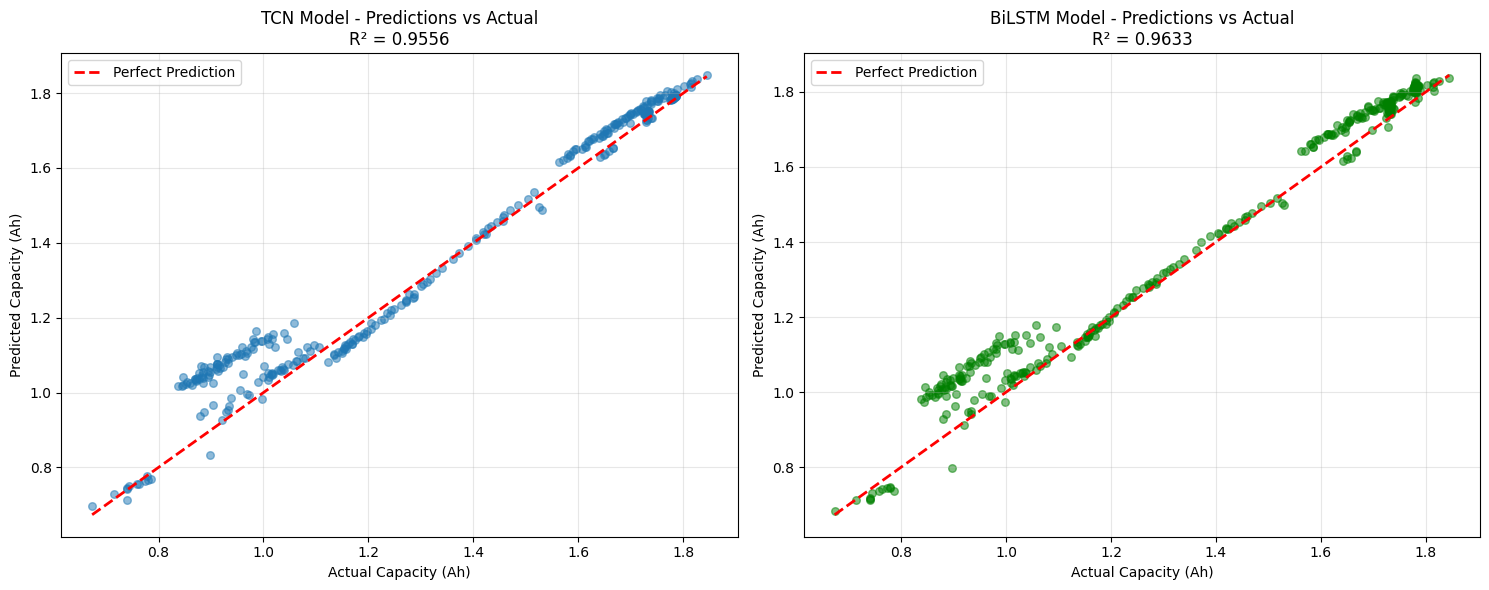

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# TCN Plot
axes[0].scatter(y_test_true, tcn_pred, alpha=0.5, s=30)
axes[0].plot([y_test_true.min(), y_test_true.max()],
             [y_test_true.min(), y_test_true.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Capacity (Ah)')
axes[0].set_ylabel('Predicted Capacity (Ah)')
axes[0].set_title(f'TCN Model - Predictions vs Actual\nR² = {tcn_metrics["R²"]:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# BiLSTM Plot
axes[1].scatter(y_test_true, bilstm_pred, alpha=0.5, s=30, color='green')
axes[1].plot([y_test_true.min(), y_test_true.max()],
             [y_test_true.min(), y_test_true.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Capacity (Ah)')
axes[1].set_ylabel('Predicted Capacity (Ah)')
axes[1].set_title(f'BiLSTM Model - Predictions vs Actual\nR² = {bilstm_metrics["R²"]:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### **8.2.3 Create Error Distribution Plots**

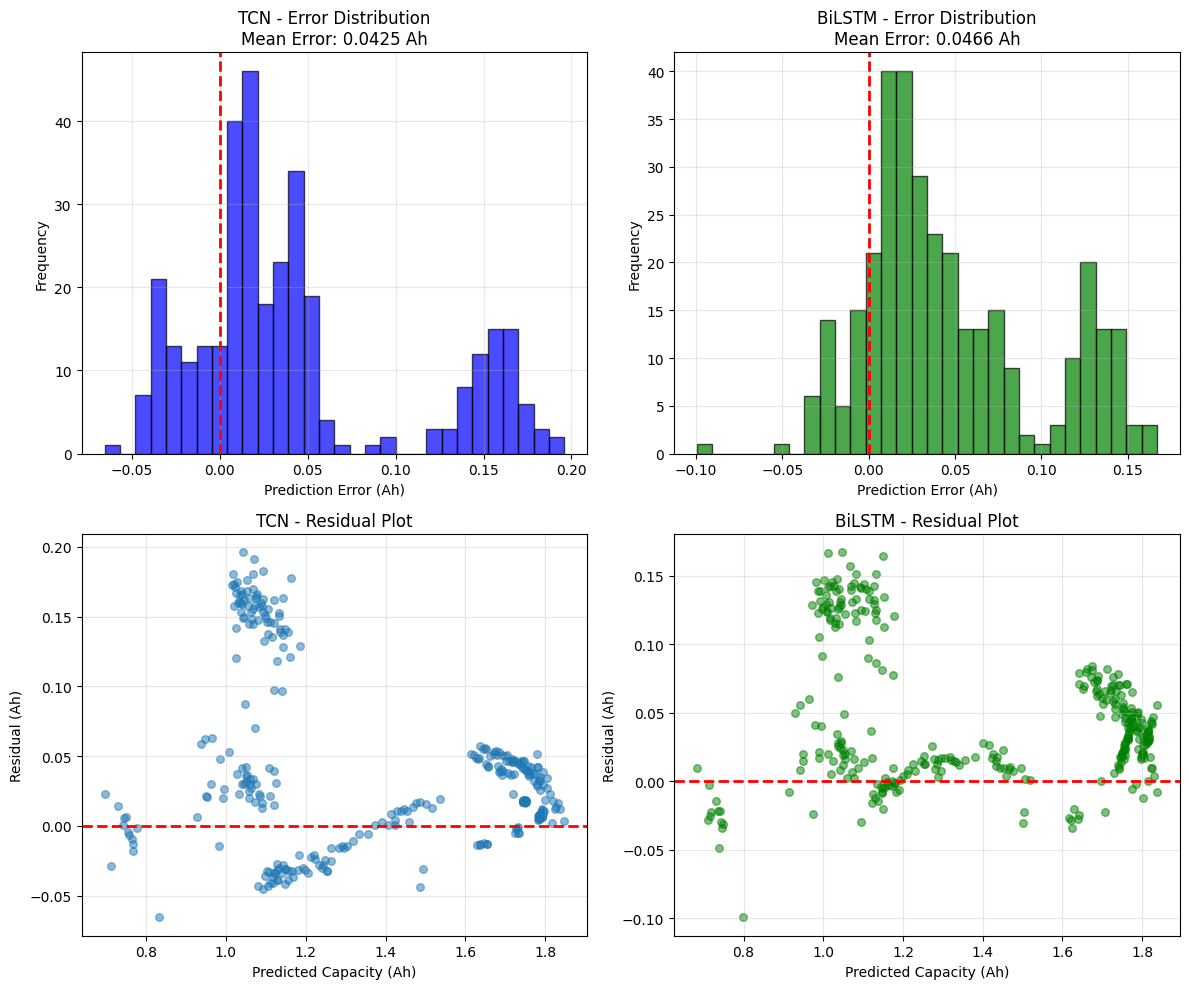

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# TCN Error Distribution
tcn_errors = tcn_pred - y_test_true
axes[0, 0].hist(tcn_errors, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Prediction Error (Ah)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'TCN - Error Distribution\nMean Error: {np.mean(tcn_errors):.4f} Ah')
axes[0, 0].grid(True, alpha=0.3)

# BiLSTM Error Distribution
bilstm_errors = bilstm_pred - y_test_true
axes[0, 1].hist(bilstm_errors, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Prediction Error (Ah)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'BiLSTM - Error Distribution\nMean Error: {np.mean(bilstm_errors):.4f} Ah')
axes[0, 1].grid(True, alpha=0.3)

# TCN Residual Plot
axes[1, 0].scatter(tcn_pred, tcn_errors, alpha=0.5, s=30)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Capacity (Ah)')
axes[1, 0].set_ylabel('Residual (Ah)')
axes[1, 0].set_title('TCN - Residual Plot')
axes[1, 0].grid(True, alpha=0.3)

# BiLSTM Residual Plot
axes[1, 1].scatter(bilstm_pred, bilstm_errors, alpha=0.5, s=30, color='green')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Predicted Capacity (Ah)')
axes[1, 1].set_ylabel('Residual (Ah)')
axes[1, 1].set_title('BiLSTM - Residual Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### **8.2.4 Per-Battery Performance Analysis**

In [ ]:
def analyze_battery_performance(model, X_seq, X_add, y_true, battery_ids, scalers, model_name):
    """
    Analyze model performance per battery
    """
    # Get predictions
    y_pred_normalized = model.predict([X_seq, X_add])
    y_pred = scalers['capacity'].inverse_transform(y_pred_normalized.reshape(-1, 1)).flatten()
    y_true_denorm = scalers['capacity'].inverse_transform(y_true.reshape(-1, 1)).flatten()

    # Calculate metrics per battery
    battery_metrics = []
    for battery in np.unique(battery_ids):
        mask = battery_ids == battery

        if np.sum(mask) > 0:
            mae = mean_absolute_error(y_true_denorm[mask], y_pred[mask])
            rmse = np.sqrt(mean_squared_error(y_true_denorm[mask], y_pred[mask]))
            r2 = r2_score(y_true_denorm[mask], y_pred[mask])

            battery_metrics.append({
                'Battery': battery,
                'Samples': np.sum(mask),
                'MAE (Ah)': mae,
                'RMSE (Ah)': rmse,
                'R²': r2
            })

    return pd.DataFrame(battery_metrics)

# Analyze per-battery performance
tcn_battery_perf = analyze_battery_performance(
    tcn_model, X_seq_test, X_add_test, y_test,
    test_data['battery_ids'], scalers, 'TCN'
)

bilstm_battery_perf = analyze_battery_performance(
    bilstm_model, X_seq_test, X_add_test, y_test,
    test_data['battery_ids'], scalers, 'BiLSTM'
)

print("\nTCN - Per Battery Performance:")
display(tcn_battery_perf.sort_values('R²', ascending=False))

print("\nBiLSTM - Per Battery Performance:")
display(bilstm_battery_perf.sort_values('R²', ascending=False))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

TCN - Per Battery Performance:


,Battery,Samples,MAE (Ah),RMSE (Ah),R²
3,B0040,43,0.014760,0.015578,0.998641
2,B0038,45,0.014184,0.019662,0.996163
4,B0046,67,0.024289,0.027393,0.955455
0,B0029,40,0.033407,0.036391,0.668938
1,B0030,40,0.043543,0.044400,0.455542
5,B0054,99,0.118082,0.131356,-2.723555



BiLSTM - Per Battery Performance:


,Battery,Samples,MAE (Ah),RMSE (Ah),R²
3,B0040,43,0.026611,0.029041,0.995277
2,B0038,45,0.027204,0.031137,0.990378
4,B0046,67,0.012041,0.014138,0.988133
0,B0029,40,0.038935,0.044728,0.499894
1,B0030,40,0.061833,0.063451,-0.111887
5,B0054,99,0.101464,0.113053,-1.758186


##### **8.2.5 Visualize Predictions for Sample Batteries**

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 370ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


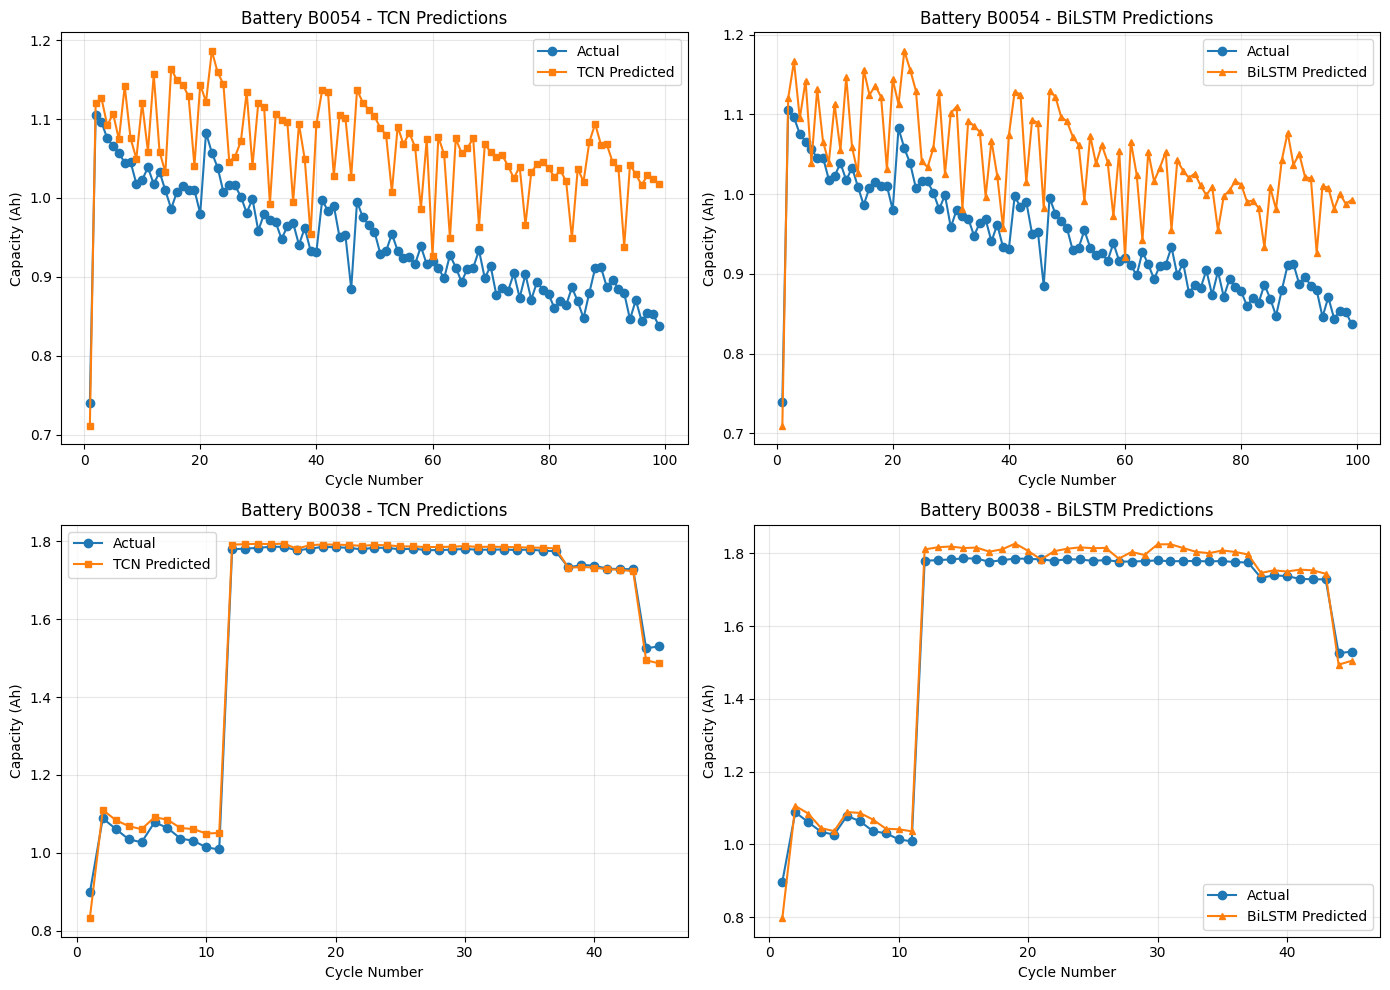

In [ ]:
# Select two test batteries to visualize
sample_batteries = test_batteries[:2]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, battery_id in enumerate(sample_batteries):
    # Get data for this battery
    battery_mask = test_data['battery_ids'] == battery_id
    battery_cycles = test_data['cycle_numbers'][battery_mask]
    battery_true = scalers['capacity'].inverse_transform(
        test_data['capacities_normalized'][battery_mask].reshape(-1, 1)
    ).flatten()

    # Get predictions
    battery_tcn_pred = scalers['capacity'].inverse_transform(
        tcn_model.predict([X_seq_test[battery_mask], X_add_test[battery_mask]])
    ).flatten()

    battery_bilstm_pred = scalers['capacity'].inverse_transform(
        bilstm_model.predict([X_seq_test[battery_mask], X_add_test[battery_mask]])
    ).flatten()

    # TCN Plot
    axes[i, 0].plot(battery_cycles, battery_true, 'o-', label='Actual', markersize=6)
    axes[i, 0].plot(battery_cycles, battery_tcn_pred, 's-', label='TCN Predicted', markersize=4)
    axes[i, 0].set_xlabel('Cycle Number')
    axes[i, 0].set_ylabel('Capacity (Ah)')
    axes[i, 0].set_title(f'Battery {battery_id} - TCN Predictions')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    # BiLSTM Plot
    axes[i, 1].plot(battery_cycles, battery_true, 'o-', label='Actual', markersize=6)
    axes[i, 1].plot(battery_cycles, battery_bilstm_pred, '^-', label='BiLSTM Predicted', markersize=4)
    axes[i, 1].set_xlabel('Cycle Number')
    axes[i, 1].set_ylabel('Capacity (Ah)')
    axes[i, 1].set_title(f'Battery {battery_id} - BiLSTM Predictions')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **9. Comparing All Model**

#### **9.1 Analyze Why Deep Learning Models Perform Better**


Complete Model Comparison:


,Model,MAE (Ah),RMSE (Ah),R²,MAPE (%)
2,Simple LSTM,0.1579,0.1996,0.6920,14.35
0,Random Forest,0.0566,0.0767,0.9545,5.30
3,TCN,0.0529,0.0758,0.9556,5.03
4,BiLSTM,0.0515,0.0689,0.9633,4.64
1,XGBoost,0.0533,0.0682,0.9640,4.90


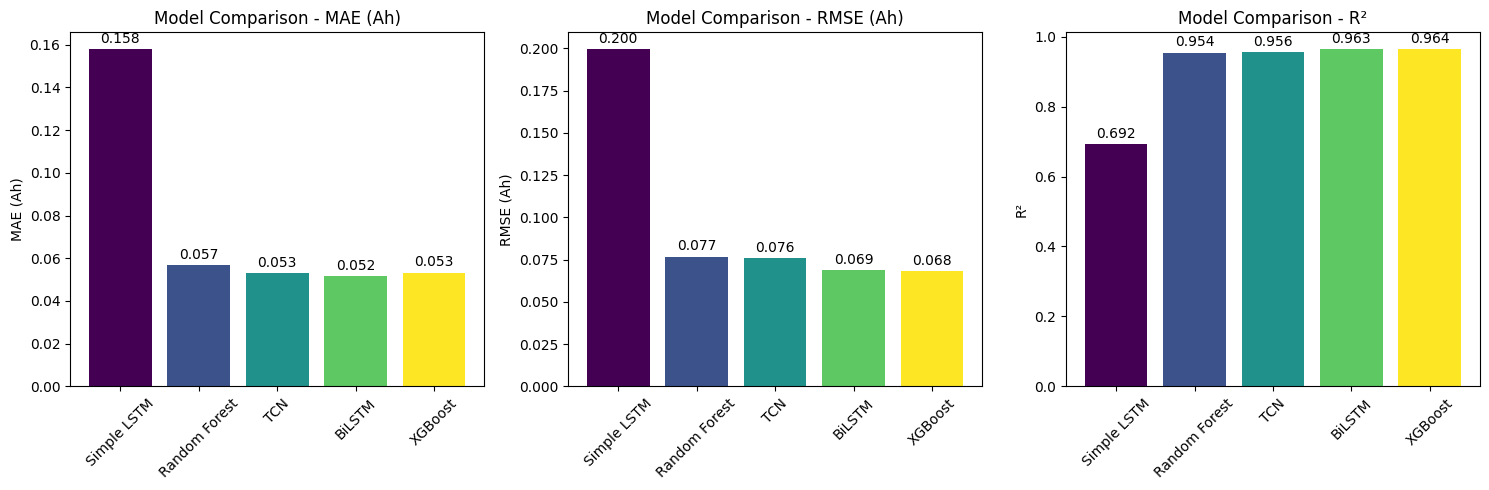

In [ ]:
# Create comparison table for all models
baseline_comparison = pd.DataFrame([
    rf_metrics,
    xgb_metrics,
    lstm_metrics,
    tcn_metrics,
    bilstm_metrics
])
baseline_comparison = baseline_comparison.sort_values('R²', ascending=True)

print("\nComplete Model Comparison:")
print("=" * 70)
display(baseline_comparison.style.format({
    'MAE (Ah)': '{:.4f}',
    'RMSE (Ah)': '{:.4f}',
    'R²': '{:.4f}',
    'MAPE (%)': '{:.2f}'
}))

# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = baseline_comparison['Model']
metrics_to_plot = ['MAE (Ah)', 'RMSE (Ah)', 'R²']

for i, metric in enumerate(metrics_to_plot):
    values = baseline_comparison[metric]
    # colors = ['blue', 'green', 'orange', 'red', 'purple']

    axes[i].bar(models, values, color=colors)
    axes[i].set_title(f'Model Comparison - {metric}')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for j, v in enumerate(values):
        axes[i].text(j, v + 0.01 * max(values), f'{v:.3f}',
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()

### **10. Save Model Results**

In [ ]:
import joblib

EXPORT_DIR = os.path.join(BASE_PATH, 'export')
os.makedirs(EXPORT_DIR, exist_ok=True)

# Save all trained models
print("Saving all trained models...")

# Save traditional ML models with joblib
joblib.dump(rf_model, os.path.join(EXPORT_DIR 'rf_model.joblib'))
joblib.dump(xgb_model, os.path.join(EXPORT_DIR, 'xgb_model.joblib'))
joblib.dump(scaler_ml, os.path.join(EXPORT_DIR, 'ml_features_scaler.joblib'))
print("Random Forest and XGBoost models saved with joblib")

# Save deep learning models in Keras format
tcn_model.save(os.path.join(EXPORT_DIR, 'tcn_model_final.keras'))
bilstm_model.save(os.path.join(EXPORT_DIR, 'bilstm_model_final.keras'))
simple_lstm.save(os.path.join(EXPORT_DIR, 'lstm_baseline_model.keras'))
print("Deep learning models saved in Keras format")

# Save all scalers for preprocessing
preprocessing_objects = {
    'sequence_scalers': scalers,
    'ml_feature_scaler': scaler_ml,
    'feature_columns': feature_cols,
    'sequence_length': X_seq_train.shape[1],
    'sequence_features': ['voltage', 'current', 'temperature'],
    'additional_feature_names': sequence_dataset['feature_names']
}

joblib.dump(preprocessing_objects, os.path.join(EXPORT_DIR, 'preprocessing_objects.joblib'))
print("Preprocessing objects saved")

# Create comparison table for deep learning models
comparison_df = pd.DataFrame([
    lstm_metrics,
    tcn_metrics,
    bilstm_metrics
])

# Save comprehensive evaluation results
all_results = {
    # Model metrics
    'tcn_metrics': tcn_metrics,
    'bilstm_metrics': bilstm_metrics,
    'lstm_metrics': lstm_metrics,
    'rf_metrics': rf_metrics,
    'xgb_metrics': xgb_metrics,

    # Predictions
    'tcn_predictions': tcn_pred,
    'bilstm_predictions': bilstm_pred,
    'lstm_predictions': lstm_pred_test,
    'rf_predictions': rf_pred_test,
    'xgb_predictions': xgb_pred_test,

    # True values and metadata
    'true_values': y_test_true,
    'test_battery_ids': test_data['battery_ids'],
    'test_cycle_numbers': test_data['cycle_numbers'],

    # Comparison tables
    'baseline_comparison_table': baseline_comparison,
    'dl_comparison_table': comparison_df,

    # Feature importance (for RF)
    'rf_feature_importance': feature_importance,

    # Model configurations
    'model_configs': {
        'tcn': {
            'sequence_shape': (X_seq_train.shape[1], X_seq_train.shape[2]),
            'additional_features_shape': X_add_train.shape[1]
        },
        'bilstm': {
            'sequence_shape': (X_seq_train.shape[1], X_seq_train.shape[2]),
            'additional_features_shape': X_add_train.shape[1]
        },
        'lstm': {
            'sequence_shape': (X_seq_train.shape[1], X_seq_train.shape[2])
        },
        'ml_models': {
            'n_features': len(feature_cols),
            'feature_names': feature_cols
        }
    }
}

# Save results
output_file = os.path.join(EXPORT_DIR, "all_model_evaluation_results.pkl")
with open(output_file, 'wb') as f:
    pickle.dump(all_results, f)
print(f"All evaluation results saved to: {output_file}")

# Create model inventory file for easy reference
model_inventory = {
    'models': {
        'Random Forest': 'rf_model.joblib',
        'XGBoost': 'xgb_model.joblib',
        'Simple LSTM': 'lstm_baseline_model.keras',
        'TCN': 'tcn_model_final.keras',
        'BiLSTM': 'bilstm_model_final.keras'
    },
    'preprocessing': {
        'all_preprocessing': 'preprocessing_objects.joblib',
        'prepared_dl_data': 'prepared_dl_data.pkl',
        'sequence_dataset': 'sequence_dataset_interpolated.pkl'
    },
    'results': {
        'evaluation_results': 'all_model_evaluation_results.pkl',
        'clean_features': 'discharge_features_clean.csv'
    },
    'model_performance': baseline_comparison.to_dict('records')
}

# Save inventory as JSON for easy reading
import json
with open(os.path.join(EXPORT_DIR, 'model_inventory.json'), 'w') as f:
    json.dump(model_inventory, f, indent=2)

print("\nModel inventory saved to model_inventory.json")
print("\nAll models and results saved successfully!")
print(f"Total files saved in {EXPORT_DIR}:")
for category, files in model_inventory.items():
    print(f"\n{category}:")
    if isinstance(files, dict):
        for name, filename in files.items():
            print(f"  - {name}: {filename}")

Saving all trained models...
Random Forest and XGBoost models saved with joblib
Deep learning models saved in Keras format
Preprocessing objects saved
All evaluation results saved to: /content/drive/MyDrive/ESCL/Projects/soh-prediction/all_model_evaluation_results.pkl

Model inventory saved to model_inventory.json

All models and results saved successfully!
Total files saved in /content/drive/MyDrive/ESCL/Projects/soh-prediction:

models:
  - Random Forest: rf_model.joblib
  - XGBoost: xgb_model.joblib
  - Simple LSTM: lstm_baseline_model.keras
  - TCN: tcn_model_final.keras
  - BiLSTM: bilstm_model_final.keras

preprocessing:
  - all_preprocessing: preprocessing_objects.joblib
  - prepared_dl_data: prepared_dl_data.pkl
  - sequence_dataset: sequence_dataset_interpolated.pkl

results:
  - evaluation_results: all_model_evaluation_results.pkl
  - clean_features: discharge_features_clean.csv

model_performance:
